# 다음 거래일 주가 방향 예측기 — 시각화 강화판

이 노트북은 `yfinance` 일봉 데이터를 이용해 **다음 거래일 종가가 상승할지 하락할지** 연구하는 프로젝트입니다.

\[
y_t =
\begin{cases}
1 & \text{if } Close_{t+1} > Close_t \\
0 & \text{otherwise}
\end{cases}
\]

전체 흐름은 다음과 같습니다.

```text
Yahoo Finance 데이터
→ 대상 종목·동일 시장 패널 구성
→ 과거 정보만으로 특징 생성
→ 시간순 워크포워드 OOF 예측
→ 여러 모델 스태킹
→ 맞을 가능성을 추정하는 메타 선택기
→ 검증 구간에서 선택 임계값 확정
→ 손대지 않은 최근 구간 독립 테스트
→ 조건을 통과한 날만 상승·하락, 나머지는 관망
```

이 프로젝트의 `80%`는 모든 거래일을 80% 맞힌다는 보장이 아닙니다. 모델이 신뢰할 만하다고 선택한 일부 거래일의 **선택 정확도**가 독립 테스트에서 80% 이상인지 검증하는 연구 목표입니다.

이 버전은 데이터 탐색, 시간 분할, 모델 성능, 확률 보정, 선택 신호와 특징 중요도를 그래프로 확인할 수 있으며 모든 그림을 결과 폴더에 PNG로 저장합니다.

## 0. 실험 원칙

다음 원칙을 지키지 않으면 높은 정확도가 나와도 결과를 신뢰할 수 없습니다.

- 오늘 이후의 가격으로 계산된 값은 입력 특징에 넣지 않습니다.
- 학습·검증·테스트를 무작위로 섞지 않고 날짜 순서대로 나눕니다.
- 정규화와 결측치 처리는 각 학습 구간에서만 적합합니다.
- 한국 주식을 예측할 때 미국 시장 정보는 한 거래일 지연합니다.
- 테스트 구간은 모델과 임계값을 모두 확정한 뒤 마지막에 한 번 평가합니다.
- 장중 미완성 일봉이 아니라 장 마감 후 확정된 일봉으로 실행합니다.

선택 정확도와 선택 비율은 함께 봐야 합니다.

\[
\text{선택 정확도}
=
\frac{\text{선택된 날 중 맞힌 날 수}}{\text{선택된 날 수}}
\]

\[
\text{선택 비율}
=
\frac{\text{상승·하락 신호를 낸 날 수}}{\text{전체 테스트 날 수}}
\]

## 1. 라이브러리 설치

Colab에서는 아래 셀을 한 번 실행합니다. 로컬 Jupyter에서는 `requirements.txt`로 설치해도 됩니다.

In [1]:
%pip install -q -U yfinance pandas numpy scikit-learn scipy joblib xgboost matplotlib

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.2 which is incompatible.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.5 which is incompatible.


## 2. 라이브러리와 설정 자료형

실행 옵션은 명령행 인자가 아니라 아래 `ResearchConfig` 객체 하나로 관리합니다. 따라서 Colab의 `-f kernel.json` 오류가 발생하지 않습니다.

In [2]:
from __future__ import annotations

import importlib.util
import json
import math
import shutil
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import joblib
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import beta, binomtest
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

@dataclass(frozen=True)
class ResearchConfig:
    ticker: str
    start: str
    target_accuracy: float
    test_days: int
    oof_days: int
    fold_days: int
    min_train_days: int
    gap_days: int
    min_calibration_signals: int
    min_test_signals: int
    min_coverage: float
    min_side_signals: int
    confidence_level: float
    refit_days: int
    mode: str
    output_dir: str
    random_state: int

Matplotlib is building the font cache; this may take a moment.


## 3. 사용자 설정

처음에는 `MODE = "fast"`로 전체 흐름이 작동하는지 확인한 뒤, 최종 연구에서는 `"full"`로 바꾸는 것이 좋습니다.

주요 설정:

- `TICKER`: Yahoo Finance 종목 코드
- `START`: 수집 시작일
- `TARGET_ACCURACY`: 선택 정확도 목표
- `TEST_DAYS`: 최종 독립 테스트 거래일 수
- `OOF_DAYS`: 스태커·선택기를 만들 워크포워드 예측 기간
- `MIN_COVERAGE`: 최소 선택 비율
- `MODE`: `fast` 또는 `full`

In [3]:
TICKER = "000660.KS"
START = "2010-01-01"
TARGET_ACCURACY = 0.80
TEST_DAYS = 252
OOF_DAYS = 756
FOLD_DAYS = 126
MIN_TRAIN_DAYS = 756
GAP_DAYS = 1
MIN_CALIBRATION_SIGNALS = 24
MIN_TEST_SIGNALS = 20
MIN_COVERAGE = 0.05
MIN_SIDE_SIGNALS = 6
CONFIDENCE_LEVEL = 0.90
REFIT_DAYS = 21
MODE = "fast"
OUTPUT_DIR = "stock80_output"
RANDOM_STATE = 42

config = ResearchConfig(
    ticker=TICKER.strip().upper(),
    start=START,
    target_accuracy=TARGET_ACCURACY,
    test_days=TEST_DAYS,
    oof_days=OOF_DAYS,
    fold_days=FOLD_DAYS,
    min_train_days=MIN_TRAIN_DAYS,
    gap_days=GAP_DAYS,
    min_calibration_signals=MIN_CALIBRATION_SIGNALS,
    min_test_signals=MIN_TEST_SIGNALS,
    min_coverage=MIN_COVERAGE,
    min_side_signals=MIN_SIDE_SIGNALS,
    confidence_level=CONFIDENCE_LEVEL,
    refit_days=REFIT_DAYS,
    mode=MODE,
    output_dir=OUTPUT_DIR,
    random_state=RANDOM_STATE,
)

if config.mode not in {"fast", "full"}:
    raise ValueError("MODE는 fast 또는 full이어야 합니다.")

if not 0.5 <= config.target_accuracy < 1:
    raise ValueError("TARGET_ACCURACY는 0.5 이상 1 미만이어야 합니다.")

display(pd.Series(asdict(config), name="설정값").to_frame())

,설정값
ticker,000660.KS
start,2010-01-01
target_accuracy,0.8
test_days,252
oof_days,756
fold_days,126
min_train_days,756
gap_days,1
min_calibration_signals,24
min_test_signals,20


## 3-1. 시각화 설정

`VISUAL_DAYS`는 탐색 그래프에 표시할 최근 거래일 수입니다. `finish_figure`는 그래프를 화면에 출력하는 동시에 `OUTPUT_DIR/figures`에 PNG로 저장합니다. Colab이나 로컬 환경에 나눔고딕이 있으면 자동으로 한글 글꼴을 적용합니다.

In [4]:
VISUAL_DAYS = 756
FIGURE_DPI = 160

figure_dir = Path(config.output_dir) / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "C:/Windows/Fonts/malgun.ttf",
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
]

for font_path in font_candidates:
    if Path(font_path).exists():
        font_name = font_manager.FontProperties(fname=font_path).get_name()
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True


def finish_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(figure_dir / filename, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close()


print(f"그래프 저장 폴더: {figure_dir.resolve()}")

그래프 저장 폴더: C:\Users\gmb98\Downloads\stock80_output\figures


## 4. 학습 패널과 시장 컨텍스트

대상 종목 하나만 학습하면 표본 수가 적고 특정 시기의 우연한 패턴에 과적합하기 쉽습니다. 그래서 같은 시장의 여러 종목을 한 데이터셋으로 묶습니다.

한국 종목의 미국 시장 변수는 `lag=1`로 설정합니다. 한국 장 마감 시점에 아직 확정되지 않은 같은 날짜의 미국 장 마감 정보를 사용하지 않기 위한 장치입니다.

In [5]:
KOREAN_PANEL = [
    "005930.KS",
    "000660.KS",
    "035420.KS",
    "035720.KS",
    "051910.KS",
    "006400.KS",
    "207940.KS",
    "005380.KS",
    "000270.KS",
    "068270.KS",
    "105560.KS",
    "055550.KS",
]

US_PANEL = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "AVGO",
    "AMD",
    "JPM",
    "XOM",
    "UNH",
    "COST",
]

KOREAN_CONTEXT = {
    "kospi": ("^KS11", 0),
    "kosdaq": ("^KQ11", 0),
    "spy": ("SPY", 1),
    "qqq": ("QQQ", 1),
    "sox": ("^SOX", 1),
    "vix": ("^VIX", 1),
    "usdkrw": ("KRW=X", 1),
}

US_CONTEXT = {
    "spy": ("SPY", 0),
    "qqq": ("QQQ", 0),
    "iwm": ("IWM", 0),
    "sox": ("^SOX", 0),
    "vix": ("^VIX", 0),
    "tnx": ("^TNX", 0),
}

META_COLUMNS = {
    "date",
    "ticker",
    "target",
    "future_return",
    "future_abs_return",
    "close_price",
    "is_latest",
}

def unique_ordered(values: list[str]) -> list[str]:
    return list(dict.fromkeys(values))

def is_korean_ticker(ticker: str) -> bool:
    upper = ticker.upper()
    return upper.endswith(".KS") or upper.endswith(".KQ")

def get_universe(ticker: str, mode: str) -> tuple[list[str], dict[str, tuple[str, int]]]:
    if is_korean_ticker(ticker):
        base = KOREAN_PANEL if mode == "full" else KOREAN_PANEL[:7]
        return unique_ordered([ticker] + base), KOREAN_CONTEXT
    base = US_PANEL if mode == "full" else US_PANEL[:7]
    return unique_ordered([ticker] + base), US_CONTEXT

## 5. 주가 데이터 수집 함수

`normalize_history`는 yfinance가 단일 인덱스 또는 다중 인덱스 컬럼을 반환하더라도 OHLCV 형식으로 통일합니다. 다운로드 실패 종목은 기록하고, 대상 종목 다운로드가 실패한 경우에만 중단합니다.

In [6]:
def import_yfinance() -> Any:
    try:
        import yfinance as yf
    except ImportError as exc:
        raise RuntimeError("yfinance가 설치되어 있지 않습니다. pip install -U yfinance를 실행하세요.") from exc
    return yf

def normalize_history(history: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if history is None or history.empty:
        return pd.DataFrame()
    frame = history.copy()
    if isinstance(frame.columns, pd.MultiIndex):
        fields = {"Open", "High", "Low", "Close", "Volume"}
        selected = None
        for level in range(frame.columns.nlevels):
            values = set(map(str, frame.columns.get_level_values(level)))
            if fields.issubset(values):
                other_levels = [i for i in range(frame.columns.nlevels) if i != level]
                if other_levels:
                    try:
                        selected = frame.xs(ticker, axis=1, level=other_levels[0], drop_level=True)
                    except Exception:
                        selected = None
                if selected is None:
                    columns = {}
                    for field in fields:
                        matches = [col for col in frame.columns if str(col[level]) == field]
                        if matches:
                            columns[field] = frame[matches[0]]
                    selected = pd.DataFrame(columns, index=frame.index)
                frame = selected
                break
    renamed = {str(column).strip().title(): column for column in frame.columns}
    required = ["Open", "High", "Low", "Close", "Volume"]
    if not all(name in renamed for name in required):
        return pd.DataFrame()
    frame = frame[[renamed[name] for name in required]].copy()
    frame.columns = required
    index = pd.to_datetime(frame.index, errors="coerce")
    if getattr(index, "tz", None) is not None:
        index = index.tz_localize(None)
    frame.index = index.normalize()
    frame = frame[~frame.index.isna()]
    frame = frame[~frame.index.duplicated(keep="last")]
    frame = frame.sort_index()
    for column in required:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=["Open", "High", "Low", "Close"])
    frame = frame[frame["Close"] > 0]
    return frame

def download_history(ticker: str, start: str) -> pd.DataFrame:
    yf = import_yfinance()
    errors: list[str] = []
    attempts = [
        {"interval": "1d", "auto_adjust": True, "actions": False, "repair": True},
        {"interval": "1d", "auto_adjust": True, "actions": False},
    ]
    for settings in attempts:
        try:
            history = yf.Ticker(ticker).history(start=start, **settings)
            normalized = normalize_history(history, ticker)
            if not normalized.empty:
                return normalized
        except Exception as exc:
            errors.append(str(exc))
    try:
        history = yf.download(
            ticker,
            start=start,
            interval="1d",
            auto_adjust=True,
            progress=False,
            threads=False,
            repair=True,
        )
        normalized = normalize_history(history, ticker)
        if not normalized.empty:
            return normalized
    except Exception as exc:
        errors.append(str(exc))
    message = " | ".join(errors[-3:])
    raise RuntimeError(f"{ticker} 데이터를 받지 못했습니다: {message}")

def download_universe(tickers: list[str], start: str) -> tuple[dict[str, pd.DataFrame], dict[str, str]]:
    histories: dict[str, pd.DataFrame] = {}
    failures: dict[str, str] = {}
    for position, ticker in enumerate(tickers, start=1):
        print(f"[{position:02d}/{len(tickers):02d}] {ticker} 다운로드")
        try:
            histories[ticker] = download_history(ticker, start)
        except Exception as exc:
            failures[ticker] = str(exc)
    return histories, failures

### 5-1. 데이터 다운로드 실행

In [7]:
panel_tickers, context_specification = get_universe(config.ticker, config.mode)
download_tickers = unique_ordered(
    panel_tickers + [ticker for ticker, _ in context_specification.values()]
)

histories, failures = download_universe(download_tickers, config.start)

if config.ticker not in histories:
    raise RuntimeError(f"대상 종목 {config.ticker} 데이터를 받지 못했습니다.")

panel_histories = {
    ticker: histories[ticker]
    for ticker in panel_tickers
    if ticker in histories
}

context_histories = {
    prefix: (histories[ticker], lag)
    for prefix, (ticker, lag) in context_specification.items()
    if ticker in histories
}

if len(panel_histories) < 4:
    raise RuntimeError("패널 종목이 4개 미만입니다. 네트워크 또는 종목 코드를 확인하세요.")

download_summary = pd.DataFrame(
    [
        {
            "ticker": ticker,
            "rows": len(history),
            "start": history.index.min().date(),
            "end": history.index.max().date(),
        }
        for ticker, history in histories.items()
    ]
).sort_values("ticker")

display(download_summary)

if failures:
    display(
        pd.DataFrame(
            [{"ticker": ticker, "error": message} for ticker, message in failures.items()]
        )
    )

[01/14] 000660.KS 다운로드
[02/14] 005930.KS 다운로드
[03/14] 035420.KS 다운로드
[04/14] 035720.KS 다운로드
[05/14] 051910.KS 다운로드
[06/14] 006400.KS 다운로드
[07/14] 207940.KS 다운로드
[08/14] ^KS11 다운로드
[09/14] ^KQ11 다운로드
[10/14] SPY 다운로드
[11/14] QQQ 다운로드
[12/14] ^SOX 다운로드
[13/14] ^VIX 다운로드
[14/14] KRW=X 다운로드


,ticker,rows,start,end
0,000660.KS,4093,2010-01-04,2026-08-24
1,005930.KS,4093,2010-01-04,2026-08-24
5,006400.KS,4093,2010-01-04,2026-08-24
2,035420.KS,4093,2010-01-04,2026-08-24
3,035720.KS,4093,2010-01-04,2026-08-24
4,051910.KS,4093,2010-01-04,2026-08-24
6,207940.KS,2393,2016-11-11,2026-08-24
13,KRW=X,4336,2010-01-01,2026-08-24
10,QQQ,4184,2010-01-04,2026-08-21
9,SPY,4184,2010-01-04,2026-08-21


## 6. 특징과 타깃 생성

### 종목 자체 특징

- 1·2·3·5·10·20·60일 수익률
- 최근 수익률의 lag
- 이동평균·EMA·MACD·RSI
- 변동성·왜도·첨도·낙폭
- ATR·볼린저 위치·스토캐스틱
- 거래량 변화·거래량 Z점수·OBV
- 갭·장중 수익률·캔들 몸통과 꼬리
- 요일·월 주기

### 외부 시장 특징

- 시장 지수 수익률
- 변동성
- 추세
- 낙폭

### 패널 특징

- 같은 날짜 다른 종목과의 상대 순위
- 시장 상승 종목 비율
- 종목 간 수익률 분산

타깃 생성에만 `shift(-1)`을 사용하고, 그 값은 특징 목록에서 제외합니다.

In [8]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan)

def rolling_slope(series: pd.Series, window: int) -> pd.Series:
    x = np.arange(window, dtype=float)
    centered = x - x.mean()
    denominator = float(np.dot(centered, centered))

    def calculate(values: np.ndarray) -> float:
        if not np.isfinite(values).all():
            return np.nan
        return float(np.dot(values, centered) / denominator)

    return series.rolling(window, min_periods=window).apply(calculate, raw=True)

def rsi(series: pd.Series, window: int) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    relative_strength = safe_divide(gain, loss)
    return 100 - 100 / (1 + relative_strength)

def build_local_features(history: pd.DataFrame, ticker: str) -> pd.DataFrame:
    frame = history.copy()
    open_price = frame["Open"]
    high = frame["High"]
    low = frame["Low"]
    close = frame["Close"]
    volume = frame["Volume"].fillna(0)
    previous_close = close.shift(1)
    log_close = np.log(close)
    log_return = log_close.diff()
    result = pd.DataFrame(index=frame.index)
    result["ticker"] = ticker
    result["close_price"] = close
    result["gap_return"] = safe_divide(open_price, previous_close) - 1
    result["intraday_return"] = safe_divide(close, open_price) - 1
    result["range_ratio"] = safe_divide(high - low, close)
    result["body_ratio"] = safe_divide((close - open_price).abs(), high - low)
    result["upper_wick_ratio"] = safe_divide(high - pd.concat([open_price, close], axis=1).max(axis=1), high - low)
    result["lower_wick_ratio"] = safe_divide(pd.concat([open_price, close], axis=1).min(axis=1) - low, high - low)
    result["close_location"] = safe_divide(close - low, high - low)
    for horizon in [1, 2, 3, 5, 10, 20, 60]:
        result[f"return_{horizon}"] = close.pct_change(horizon)
    for lag in range(1, 11):
        result[f"log_return_lag_{lag}"] = log_return.shift(lag - 1)
    for window in [5, 10, 20, 60]:
        rolling_returns = log_return.rolling(window, min_periods=window)
        result[f"return_mean_{window}"] = rolling_returns.mean()
        result[f"volatility_{window}"] = rolling_returns.std()
        result[f"return_skew_{window}"] = rolling_returns.skew()
        result[f"return_kurt_{window}"] = rolling_returns.kurt()
        result[f"price_sma_ratio_{window}"] = safe_divide(close, close.rolling(window, min_periods=window).mean()) - 1
        result[f"trend_slope_{window}"] = rolling_slope(log_close, window)
        result[f"drawdown_{window}"] = safe_divide(close, close.rolling(window, min_periods=window).max()) - 1
    for window in [5, 12, 26, 60]:
        ema = close.ewm(span=window, adjust=False, min_periods=window).mean()
        result[f"price_ema_ratio_{window}"] = safe_divide(close, ema) - 1
    ema_12 = close.ewm(span=12, adjust=False, min_periods=12).mean()
    ema_26 = close.ewm(span=26, adjust=False, min_periods=26).mean()
    macd = safe_divide(ema_12 - ema_26, close)
    macd_signal = macd.ewm(span=9, adjust=False, min_periods=9).mean()
    result["macd"] = macd
    result["macd_signal"] = macd_signal
    result["macd_histogram"] = macd - macd_signal
    for window in [7, 14, 28]:
        result[f"rsi_{window}"] = rsi(close, window) / 100
    true_range = pd.concat(
        [high - low, (high - previous_close).abs(), (low - previous_close).abs()], axis=1
    ).max(axis=1)
    result["atr_14"] = safe_divide(true_range.rolling(14, min_periods=14).mean(), close)
    middle = close.rolling(20, min_periods=20).mean()
    deviation = close.rolling(20, min_periods=20).std()
    result["bollinger_z_20"] = safe_divide(close - middle, deviation)
    rolling_low = low.rolling(14, min_periods=14).min()
    rolling_high = high.rolling(14, min_periods=14).max()
    stochastic = safe_divide(close - rolling_low, rolling_high - rolling_low)
    result["stochastic_14"] = stochastic
    result["stochastic_signal_3"] = stochastic.rolling(3, min_periods=3).mean()
    log_volume = np.log1p(volume.clip(lower=0))
    result["volume_change_1"] = volume.pct_change().replace([np.inf, -np.inf], np.nan)
    result["volume_change_5"] = volume.pct_change(5).replace([np.inf, -np.inf], np.nan)
    for window in [5, 20, 60]:
        volume_mean = log_volume.rolling(window, min_periods=window).mean()
        volume_std = log_volume.rolling(window, min_periods=window).std()
        result[f"volume_z_{window}"] = safe_divide(log_volume - volume_mean, volume_std)
        result[f"volume_ratio_{window}"] = safe_divide(volume, volume.rolling(window, min_periods=window).mean()) - 1
    signed_volume = np.sign(close.diff()).fillna(0) * volume
    obv = signed_volume.cumsum()
    result["obv_slope_10"] = rolling_slope(obv, 10)
    result["obv_slope_20"] = rolling_slope(obv, 20)
    weekday = result.index.dayofweek
    month = result.index.month
    result["weekday_sin"] = np.sin(2 * np.pi * weekday / 5)
    result["weekday_cos"] = np.cos(2 * np.pi * weekday / 5)
    result["month_sin"] = np.sin(2 * np.pi * month / 12)
    result["month_cos"] = np.cos(2 * np.pi * month / 12)
    future_return = close.shift(-1) / close - 1
    result["future_return"] = future_return
    result["future_abs_return"] = future_return.abs()
    result["target"] = np.where(future_return.notna(), (future_return > 0).astype(float), np.nan)
    result["is_latest"] = False
    valid_latest = result.drop(columns=["target", "future_return", "future_abs_return"]).replace([np.inf, -np.inf], np.nan)
    if not valid_latest.empty:
        result.loc[result.index[-1], "is_latest"] = True
    return result

In [9]:
def build_context_features(history: pd.DataFrame, prefix: str, lag: int) -> pd.DataFrame:
    close = history["Close"]
    log_return = np.log(close).diff()
    result = pd.DataFrame(index=history.index)
    for horizon in [1, 2, 5, 10, 20, 60]:
        result[f"context_{prefix}_return_{horizon}"] = close.pct_change(horizon)
    for window in [5, 20, 60]:
        result[f"context_{prefix}_volatility_{window}"] = log_return.rolling(window, min_periods=window).std()
        result[f"context_{prefix}_trend_{window}"] = safe_divide(close, close.rolling(window, min_periods=window).mean()) - 1
        result[f"context_{prefix}_drawdown_{window}"] = safe_divide(close, close.rolling(window, min_periods=window).max()) - 1
    if lag > 0:
        result = result.shift(lag)
    return result

def build_panel_dataset(
    target_ticker: str,
    panel_histories: dict[str, pd.DataFrame],
    context_histories: dict[str, tuple[pd.DataFrame, int]],
) -> tuple[pd.DataFrame, list[str]]:
    local_frames = [build_local_features(history, ticker) for ticker, history in panel_histories.items()]
    if not local_frames:
        raise RuntimeError("학습 가능한 패널 데이터가 없습니다.")
    context_frames = []
    for prefix, (history, lag) in context_histories.items():
        context_frames.append(build_context_features(history, prefix, lag))
    context_matrix = pd.concat(context_frames, axis=1).sort_index() if context_frames else pd.DataFrame()
    merged_frames = []
    for local in local_frames:
        merged = local.copy()
        if not context_matrix.empty:
            aligned = context_matrix.reindex(merged.index).ffill(limit=5)
            merged = merged.join(aligned, how="left")
        merged_frames.append(merged)
    panel = pd.concat(merged_frames, axis=0)
    panel.index.name = "date"
    panel = panel.reset_index()
    panel = panel.sort_values(["date", "ticker"]).reset_index(drop=True)
    for column in ["return_1", "return_5", "return_20", "volume_z_20", "volatility_20"]:
        if column not in panel.columns:
            continue
        grouped = panel.groupby("date", sort=False)[column]
        panel[f"cross_rank_{column}"] = grouped.rank(pct=True, method="average")
        panel[f"cross_mean_{column}"] = grouped.transform("mean")
        panel[f"cross_std_{column}"] = grouped.transform("std")
        panel[f"relative_{column}"] = panel[column] - panel[f"cross_mean_{column}"]
    panel["market_breadth"] = panel.groupby("date", sort=False)["return_1"].transform(lambda values: (values > 0).mean())
    panel["market_dispersion"] = panel.groupby("date", sort=False)["return_1"].transform("std")
    ticker_dummies = pd.get_dummies(panel["ticker"], prefix="ticker_id", dtype=float)
    panel = pd.concat([panel, ticker_dummies], axis=1)
    panel = panel.replace([np.inf, -np.inf], np.nan)
    feature_columns = [
        column
        for column in panel.columns
        if column not in META_COLUMNS and column != "date" and pd.api.types.is_numeric_dtype(panel[column])
    ]
    feature_availability = panel[feature_columns].notna().mean(axis=1)
    panel = panel[(feature_availability >= 0.70) | panel["is_latest"]].reset_index(drop=True)
    target_rows = panel[panel["ticker"] == target_ticker]
    if target_rows.empty:
        raise RuntimeError(f"{target_ticker}가 최종 패널에 없습니다.")
    return panel, feature_columns

### 6-1. 모델링 테이블 생성과 기본 점검

In [10]:
dataset, feature_columns = build_panel_dataset(
    config.ticker,
    panel_histories,
    context_histories,
)

target_dataset = dataset[dataset["ticker"] == config.ticker].sort_values("date")
labeled_target_dataset = target_dataset[target_dataset["target"].notna()]

overview = pd.DataFrame(
    {
        "항목": [
            "전체 패널 행 수",
            "특징 수",
            "대상 종목 학습 행 수",
            "대상 종목 상승 비율",
            "대상 종목 시작일",
            "대상 종목 마지막 확정 타깃 날짜",
        ],
        "값": [
            len(dataset),
            len(feature_columns),
            len(labeled_target_dataset),
            labeled_target_dataset["target"].mean(),
            labeled_target_dataset["date"].min().date(),
            labeled_target_dataset["date"].max().date(),
        ],
    }
)

display(overview)
display(target_dataset[["date", "ticker", "close_price", "return_1", "volatility_20", "target"]].tail())

C:\Users\gmb98\AppData\Local\Temp\ipykernel_123484\3183533313.py:26: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  context_matrix = pd.concat(context_frames, axis=1).sort_index() if context_frames else pd.DataFrame()
C:\Users\gmb98\AppData\Local\Temp\ipykernel_123484\3183533313.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel = panel.reset_index()
C:\Users\gmb98\AppData\Local\Temp\ipykernel_123484\3183533313.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

,항목,값
0,전체 패널 행 수,26827
1,특징 수,214
2,대상 종목 학습 행 수,4072
3,대상 종목 상승 비율,0.493615
4,대상 종목 시작일,2010-02-01
5,대상 종목 마지막 확정 타깃 날짜,2026-08-21


,date,ticker,close_price,return_1,volatility_20,target
26792,2026-08-18,000660.KS,1662000.0,0.010334,0.089772,0.0
26799,2026-08-19,000660.KS,1500000.0,-0.097473,0.091816,1.0
26806,2026-08-20,000660.KS,1691000.0,0.127333,0.096316,1.0
26813,2026-08-21,000660.KS,1730000.0,0.023063,0.095779,0.0
26820,2026-08-24,000660.KS,1671000.0,-0.034104,0.094124,NaN


### 6-2. 데이터 탐색 시각화

모델을 학습하기 전에 가격 추세, 거래량, 수익률 분포, 변동성, 클래스 균형과 주요 특징 간 상관관계를 확인합니다. 급등락이나 변동성 변화가 특정 구간에 몰려 있는지 먼저 보는 것이 중요합니다.

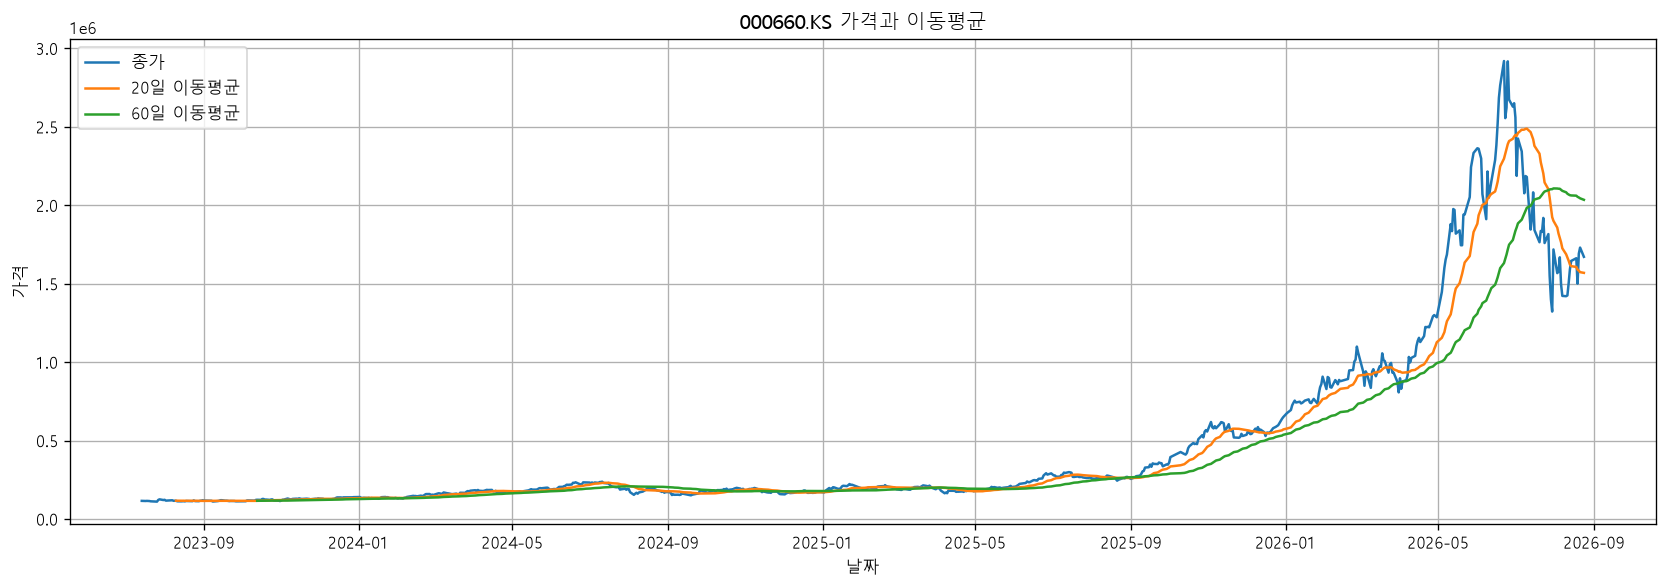

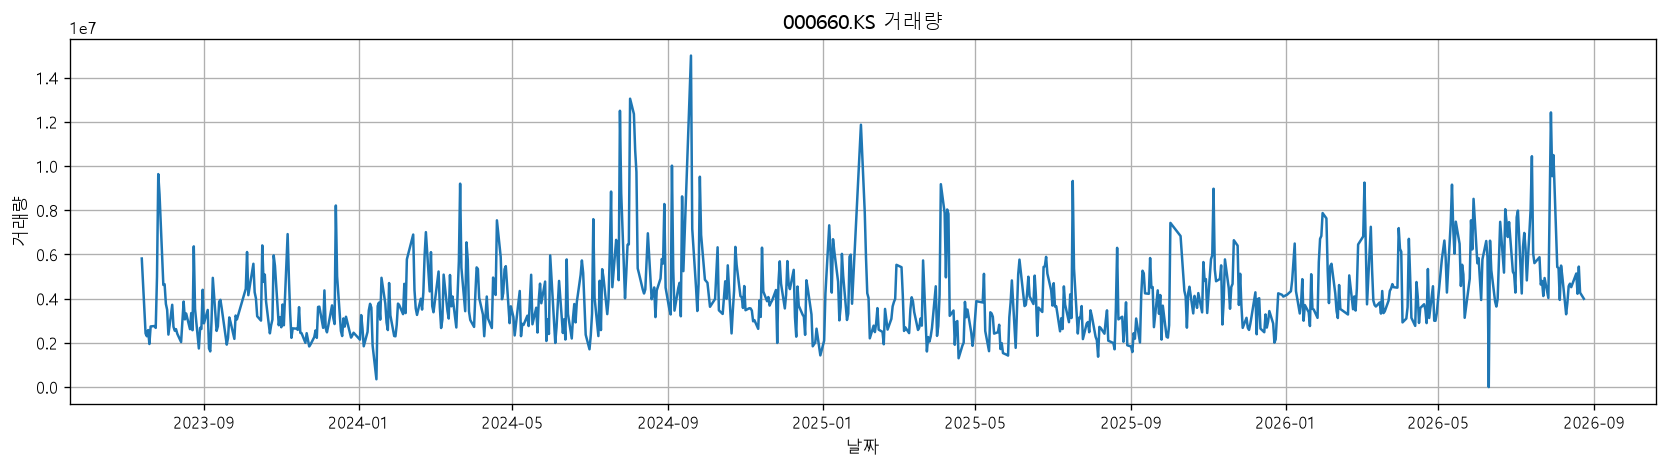

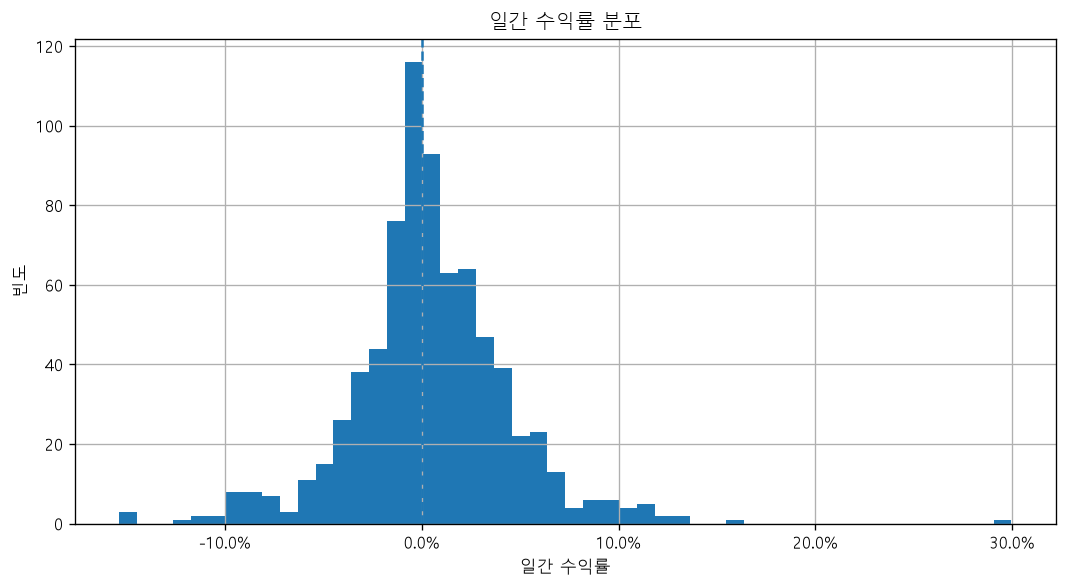

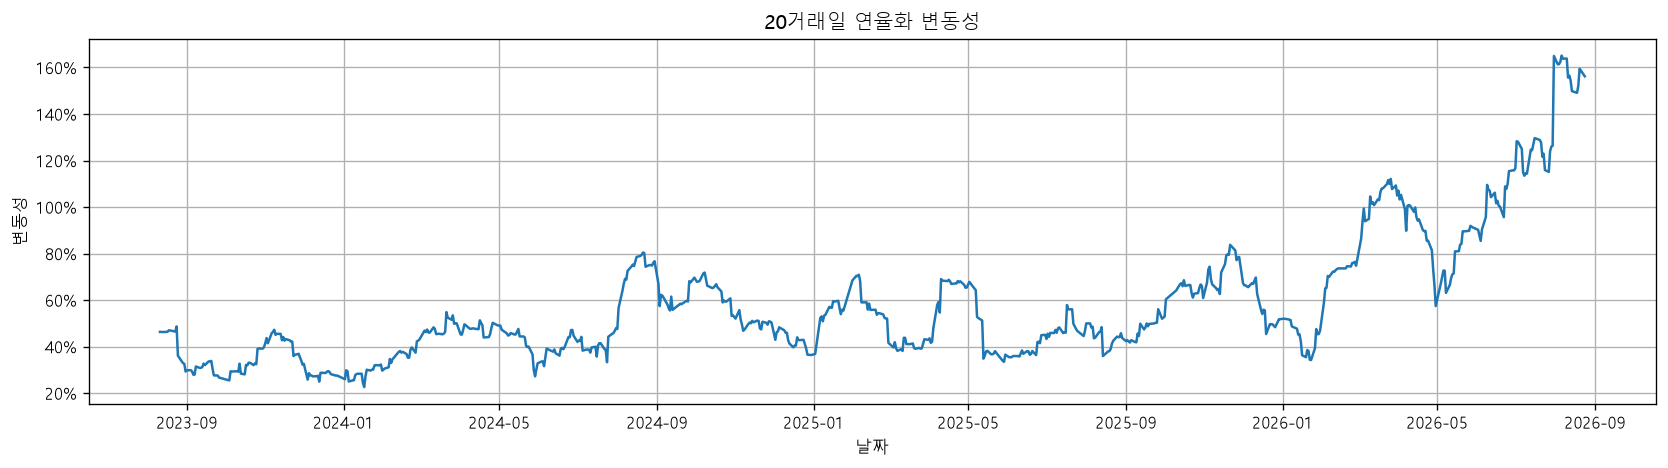

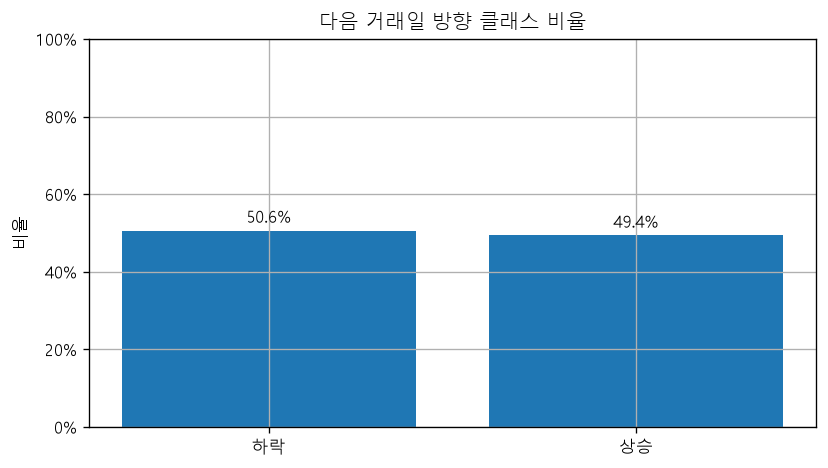

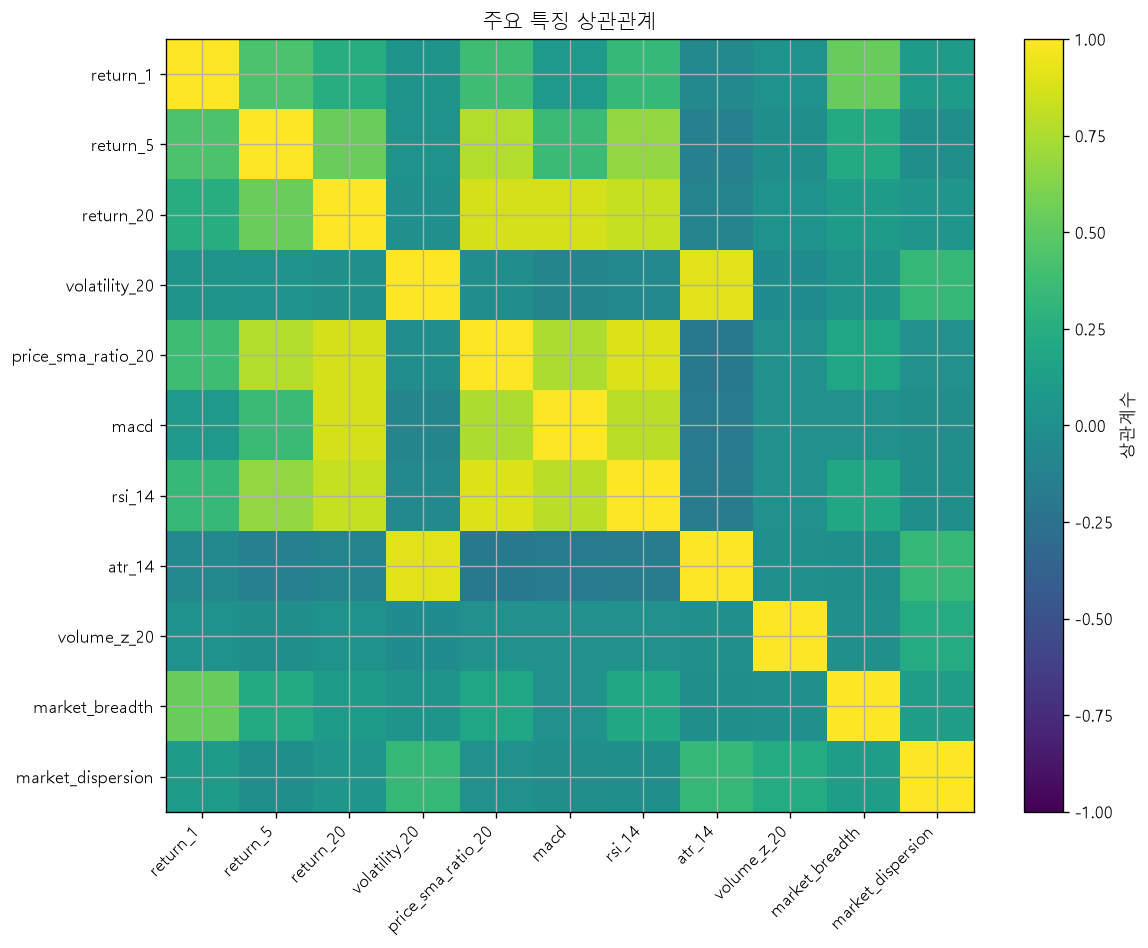

In [11]:
raw_target_history = histories[config.ticker].sort_index().copy()
visual_history = raw_target_history.tail(VISUAL_DAYS).copy()
visual_history["MA20"] = visual_history["Close"].rolling(20).mean()
visual_history["MA60"] = visual_history["Close"].rolling(60).mean()
visual_history["daily_return"] = visual_history["Close"].pct_change()
visual_history["annualized_volatility_20"] = visual_history["daily_return"].rolling(20).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
plt.plot(visual_history.index, visual_history["Close"], label="종가")
plt.plot(visual_history.index, visual_history["MA20"], label="20일 이동평균")
plt.plot(visual_history.index, visual_history["MA60"], label="60일 이동평균")
plt.title(f"{config.ticker} 가격과 이동평균")
plt.xlabel("날짜")
plt.ylabel("가격")
plt.legend()
finish_figure("01_price_moving_averages.png")

plt.figure(figsize=(14, 4))
plt.plot(visual_history.index, visual_history["Volume"])
plt.title(f"{config.ticker} 거래량")
plt.xlabel("날짜")
plt.ylabel("거래량")
finish_figure("02_volume.png")

return_values = visual_history["daily_return"].dropna()
plt.figure(figsize=(9, 5))
plt.hist(return_values, bins=50)
plt.axvline(0, linestyle="--")
plt.title("일간 수익률 분포")
plt.xlabel("일간 수익률")
plt.ylabel("빈도")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
finish_figure("03_daily_return_distribution.png")

plt.figure(figsize=(14, 4))
plt.plot(visual_history.index, visual_history["annualized_volatility_20"])
plt.title("20거래일 연율화 변동성")
plt.xlabel("날짜")
plt.ylabel("변동성")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
finish_figure("04_rolling_volatility.png")

class_balance = labeled_target_dataset["target"].value_counts(normalize=True).sort_index()
class_balance = class_balance.reindex([0.0, 1.0], fill_value=0)
class_balance.index = ["하락", "상승"]

plt.figure(figsize=(7, 4))
plt.bar(class_balance.index, class_balance.values)
plt.title("다음 거래일 방향 클래스 비율")
plt.ylabel("비율")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
for position, value in enumerate(class_balance.values):
    plt.text(position, value + 0.02, f"{value:.1%}", ha="center")
finish_figure("05_target_class_balance.png")

correlation_candidates = [
    "return_1",
    "return_5",
    "return_20",
    "volatility_20",
    "price_sma_ratio_20",
    "macd",
    "rsi_14",
    "atr_14",
    "volume_z_20",
    "market_breadth",
    "market_dispersion",
]
correlation_columns = [column for column in correlation_candidates if column in target_dataset.columns]
correlation_matrix = target_dataset[correlation_columns].corr()

figure, axis = plt.subplots(figsize=(10, 8))
image = axis.imshow(correlation_matrix.to_numpy(), vmin=-1, vmax=1, aspect="auto")
axis.set_xticks(np.arange(len(correlation_columns)))
axis.set_yticks(np.arange(len(correlation_columns)))
axis.set_xticklabels(correlation_columns, rotation=45, ha="right")
axis.set_yticklabels(correlation_columns)
axis.set_title("주요 특징 상관관계")
figure.colorbar(image, ax=axis, label="상관계수")
finish_figure("06_feature_correlation.png")

## 7. 시간순 분리와 워크포워드

무작위 분할 대신 과거로 학습하고 그 다음 구간을 검증합니다.

`GAP_DAYS = 1`은 학습 마지막 행의 타깃이 검증 첫날 가격을 참조하는 경계 누수를 막기 위한 간격입니다.

```text
학습 구간 | gap | 검증 구간
학습 구간 확장 | gap | 다음 검증 구간
...
개발 구간 | gap | 최종 테스트 구간
```

In [12]:
def make_walk_forward_splits(
    dates: pd.DatetimeIndex,
    oof_days: int,
    fold_days: int,
    min_train_days: int,
    gap_days: int,
    max_train_days: int | None,
) -> list[tuple[pd.DatetimeIndex, pd.DatetimeIndex]]:
    unique_dates = pd.DatetimeIndex(sorted(pd.unique(dates)))
    start_position = max(min_train_days + gap_days, len(unique_dates) - oof_days)
    splits: list[tuple[pd.DatetimeIndex, pd.DatetimeIndex]] = []
    validation_start = start_position
    while validation_start < len(unique_dates):
        validation_end = min(validation_start + fold_days, len(unique_dates))
        training_end = validation_start - gap_days
        if training_end < min_train_days:
            validation_start = validation_end
            continue
        training_start = 0 if max_train_days is None else max(0, training_end - max_train_days)
        training_dates = unique_dates[training_start:training_end]
        validation_dates = unique_dates[validation_start:validation_end]
        if len(training_dates) >= min_train_days and len(validation_dates) > 0:
            splits.append((training_dates, validation_dates))
        validation_start = validation_end
    return splits

In [13]:
labeled_target = dataset[
    (dataset["ticker"] == config.ticker)
    & dataset["target"].notna()
].sort_values("date")

target_dates = pd.DatetimeIndex(pd.unique(labeled_target["date"]))
required_dates = (
    config.test_days
    + config.gap_days
    + config.min_train_days
    + config.oof_days // 2
)

if len(target_dates) < required_dates:
    raise RuntimeError(
        f"대상 종목 거래일이 부족합니다. 필요 약 {required_dates}일, 현재 {len(target_dates)}일입니다."
    )

test_dates = target_dates[-config.test_days:]
development_end_position = len(target_dates) - config.test_days - config.gap_days
development_dates = target_dates[:development_end_position]

date_split_table = pd.DataFrame(
    [
        {
            "구간": "개발",
            "시작": development_dates[0].date(),
            "종료": development_dates[-1].date(),
            "거래일 수": len(development_dates),
        },
        {
            "구간": "gap",
            "시작": target_dates[development_end_position].date(),
            "종료": target_dates[development_end_position + config.gap_days - 1].date(),
            "거래일 수": config.gap_days,
        },
        {
            "구간": "최종 테스트",
            "시작": test_dates[0].date(),
            "종료": test_dates[-1].date(),
            "거래일 수": len(test_dates),
        },
    ]
)

display(date_split_table)

,구간,시작,종료,거래일 수
0,개발,2010-02-01,2025-08-06,3819
1,gap,2025-08-07,2025-08-07,1
2,최종 테스트,2025-08-08,2026-08-21,252


### 7-1. 개발·gap·테스트 구간 시각화

종가 위에 개발 구간, 경계 누수를 막는 `gap`, 손대지 않은 최종 테스트 구간을 표시합니다. 테스트 구간이 시간축의 가장 마지막에 놓여 있는지 시각적으로 확인할 수 있습니다.

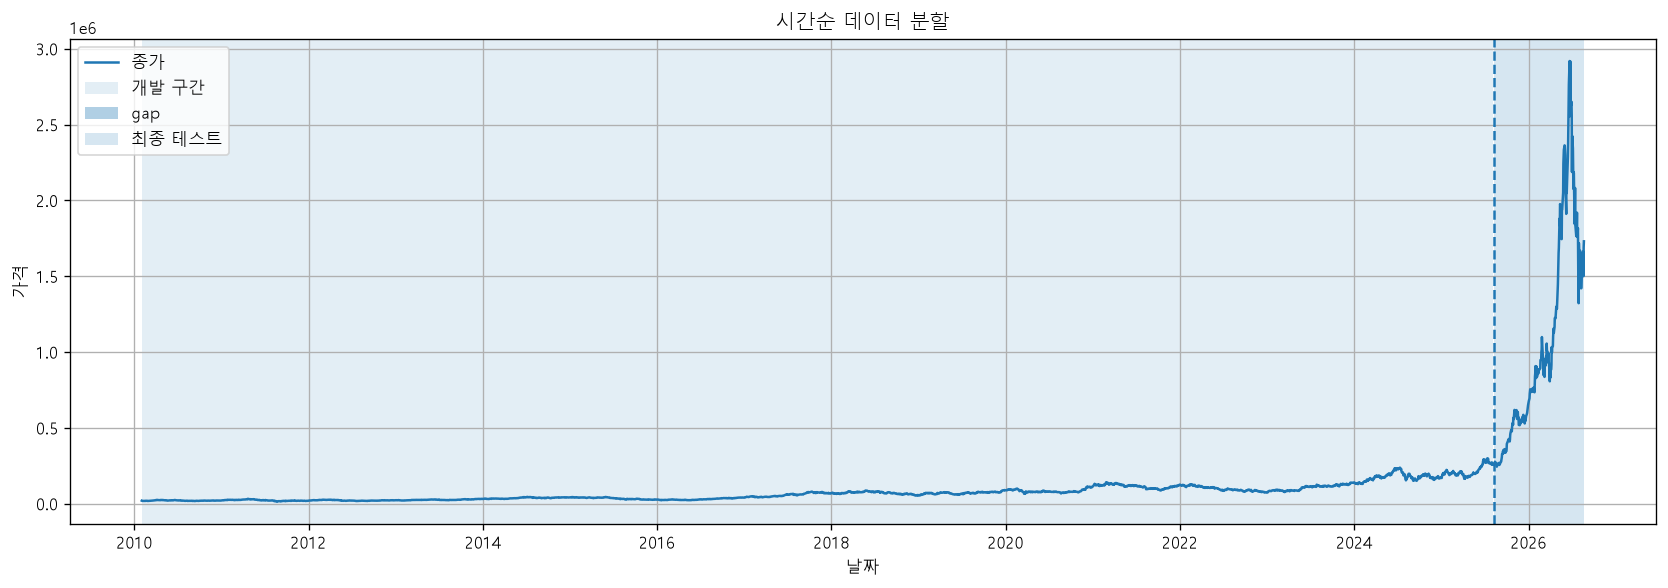

In [14]:
gap_start = target_dates[development_end_position]
gap_end = target_dates[development_end_position + config.gap_days - 1]
split_price = raw_target_history.loc[development_dates[0]:test_dates[-1], "Close"]

plt.figure(figsize=(14, 5))
plt.plot(split_price.index, split_price.values, label="종가")
plt.axvspan(development_dates[0], development_dates[-1], alpha=0.12, label="개발 구간")
plt.axvspan(gap_start, gap_end, alpha=0.35, label="gap")
plt.axvspan(test_dates[0], test_dates[-1], alpha=0.18, label="최종 테스트")
plt.axvline(test_dates[0], linestyle="--")
plt.title("시간순 데이터 분할")
plt.xlabel("날짜")
plt.ylabel("가격")
plt.legend()
finish_figure("07_chronological_split.png")

## 8. 기본 모델과 OOF 예측

기본 모델은 서로 다른 방식으로 패턴을 학습합니다.

- `LogisticRegression`: 선형 관계와 방향성을 안정적으로 학습
- `ExtraTreesClassifier`: 비선형 조건과 변수 상호작용 학습
- `HistGradientBoostingClassifier`: 순차적으로 오류를 보정
- `XGBoost`: `full` 모드에서만 추가

각 검증 행은 그 날짜보다 과거인 데이터로 학습된 모델에서만 예측됩니다. 이렇게 만든 예측을 OOF(out-of-fold) 예측이라고 합니다.

In [15]:
def build_models(mode: str, random_state: int) -> dict[str, Pipeline]:
    models: dict[str, Pipeline] = {
        "logistic": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        C=0.08,
                        max_iter=4000,
                        solver="liblinear",
                        class_weight="balanced",
                        random_state=random_state,
                    ),
                ),
            ]
        ),
        "extra_trees": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500 if mode == "full" else 280,
                        max_depth=9,
                        min_samples_leaf=18,
                        max_features=0.55,
                        class_weight="balanced_subsample",
                        n_jobs=-1,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
        "hist_gradient": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        learning_rate=0.035,
                        max_iter=350 if mode == "full" else 220,
                        max_leaf_nodes=15,
                        max_depth=5,
                        min_samples_leaf=28,
                        l2_regularization=8.0,
                        early_stopping=True,
                        validation_fraction=0.15,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
    }
    if mode == "full" and importlib.util.find_spec("xgboost") is not None:
        from xgboost import XGBClassifier

        models["xgboost"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                (
                    "model",
                    XGBClassifier(
                        n_estimators=520,
                        max_depth=3,
                        learning_rate=0.03,
                        min_child_weight=18,
                        subsample=0.82,
                        colsample_bytree=0.68,
                        reg_alpha=0.6,
                        reg_lambda=12.0,
                        gamma=0.05,
                        objective="binary:logistic",
                        eval_metric="logloss",
                        tree_method="hist",
                        n_jobs=-1,
                        random_state=random_state,
                    ),
                ),
            ]
        )
    return models

def fit_predict_models(
    models: dict[str, Pipeline],
    train_x: pd.DataFrame,
    train_y: pd.Series,
    predict_x: pd.DataFrame,
) -> tuple[dict[str, Pipeline], pd.DataFrame]:
    fitted: dict[str, Pipeline] = {}
    probabilities: dict[str, np.ndarray] = {}
    for name, model in models.items():
        candidate = clone(model)
        candidate.fit(train_x, train_y)
        fitted[name] = candidate
        probabilities[name] = candidate.predict_proba(predict_x)[:, 1]
    return fitted, pd.DataFrame(probabilities, index=predict_x.index)

def generate_oof_predictions(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    development_dates: pd.DatetimeIndex,
    config: ResearchConfig,
    max_train_days: int | None,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    splits = make_walk_forward_splits(
        development_dates,
        config.oof_days,
        config.fold_days,
        config.min_train_days,
        config.gap_days,
        max_train_days,
    )
    if len(splits) < 3:
        raise RuntimeError("워크포워드 폴드가 3개 미만입니다. 시작 날짜를 더 과거로 설정하세요.")
    models = build_models(config.mode, config.random_state)
    all_predictions: list[pd.DataFrame] = []
    fold_records: list[dict[str, Any]] = []
    for fold_number, (training_dates, validation_dates) in enumerate(splits, start=1):
        train_mask = dataset["date"].isin(training_dates) & dataset["target"].notna()
        validation_mask = dataset["date"].isin(validation_dates) & dataset["target"].notna()
        train = dataset.loc[train_mask]
        validation = dataset.loc[validation_mask]
        if train.empty or validation.empty:
            continue
        train_y = train["target"].astype(int)
        if train_y.nunique() < 2:
            continue
        print(
            f"윈도우={max_train_days or 'expanding'} 폴드={fold_number}/{len(splits)} "
            f"학습={training_dates[0].date()}~{training_dates[-1].date()} "
            f"검증={validation_dates[0].date()}~{validation_dates[-1].date()}"
        )
        _, fold_probabilities = fit_predict_models(
            models,
            train[feature_columns],
            train_y,
            validation[feature_columns],
        )
        fold_output = validation[["date", "ticker", "target"]].copy()
        for name in fold_probabilities.columns:
            fold_output[f"prob_{name}"] = fold_probabilities[name].to_numpy()
        all_predictions.append(fold_output)
        target_fold = fold_output[fold_output["ticker"] == config.ticker]
        if not target_fold.empty:
            mean_probability = target_fold.filter(like="prob_").mean(axis=1)
            prediction = (mean_probability >= 0.5).astype(int)
            fold_records.append(
                {
                    "fold": fold_number,
                    "train_start": str(training_dates[0].date()),
                    "train_end": str(training_dates[-1].date()),
                    "validation_start": str(validation_dates[0].date()),
                    "validation_end": str(validation_dates[-1].date()),
                    "samples": int(len(target_fold)),
                    "accuracy": float(accuracy_score(target_fold["target"].astype(int), prediction)),
                }
            )
    if not all_predictions:
        raise RuntimeError("OOF 예측을 생성하지 못했습니다.")
    result = pd.concat(all_predictions, axis=0).sort_values(["date", "ticker"])
    return result, fold_records

## 9. 스태킹과 메타 선택기

### 스태커

여러 기본 모델의 상승 확률을 다시 입력으로 받아 최종 상승 확률을 만듭니다. 스태커는 기본 모델의 학습 데이터 예측이 아니라 OOF 예측으로 학습합니다.

### 메타 선택기

최종 방향 예측이 맞을 가능성을 별도로 추정합니다.

- 방향 모델 출력: 상승 확률
- 선택기 출력: 이 방향 예측이 맞을 것으로 보는 점수
- 선택 점수가 임계값 이상: 상승 또는 하락 신호
- 선택 점수가 임계값 미만: 관망

In [16]:
def build_stack_features(probability_frame: pd.DataFrame) -> pd.DataFrame:
    probability_columns = [column for column in probability_frame.columns if column.startswith("prob_")]
    result = probability_frame[probability_columns].copy()
    clipped = result.clip(1e-5, 1 - 1e-5)
    for column in probability_columns:
        result[f"logit_{column}"] = np.log(clipped[column] / (1 - clipped[column]))
    result["probability_mean"] = probability_frame[probability_columns].mean(axis=1)
    result["probability_std"] = probability_frame[probability_columns].std(axis=1).fillna(0)
    result["probability_min"] = probability_frame[probability_columns].min(axis=1)
    result["probability_max"] = probability_frame[probability_columns].max(axis=1)
    result["raw_confidence"] = (result["probability_mean"] - 0.5).abs() * 2
    return result

def split_oof_dates(oof: pd.DataFrame) -> tuple[pd.DatetimeIndex, pd.DatetimeIndex, pd.DatetimeIndex]:
    dates = pd.DatetimeIndex(sorted(pd.unique(oof["date"])))
    if len(dates) < 180:
        raise RuntimeError("OOF 기간이 너무 짧습니다. oof_days를 늘리세요.")
    first_cut = max(1, int(len(dates) * 0.50))
    second_cut = max(first_cut + 1, int(len(dates) * 0.75))
    return dates[:first_cut], dates[first_cut:second_cut], dates[second_cut:]

def fit_stacker(oof: pd.DataFrame, stack_train_dates: pd.DatetimeIndex) -> Pipeline:
    stack_train = oof[oof["date"].isin(stack_train_dates)]
    x = build_stack_features(stack_train)
    y = stack_train["target"].astype(int)
    stacker = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=0.12,
                    max_iter=3000,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )
    stacker.fit(x, y)
    return stacker

def apply_stacker(stacker: Pipeline, probability_frame: pd.DataFrame) -> np.ndarray:
    return stacker.predict_proba(build_stack_features(probability_frame))[:, 1]

In [17]:
def selector_feature_names(feature_columns: list[str]) -> list[str]:
    preferred = [
        "return_1",
        "return_2",
        "return_5",
        "return_20",
        "volatility_5",
        "volatility_20",
        "volatility_60",
        "rsi_14",
        "bollinger_z_20",
        "atr_14",
        "volume_z_20",
        "market_breadth",
        "market_dispersion",
        "cross_rank_return_1",
        "cross_rank_return_5",
        "relative_return_1",
        "relative_return_5",
    ]
    context_candidates = [
        column
        for column in feature_columns
        if column.startswith("context_") and (column.endswith("return_1") or column.endswith("volatility_20") or column.endswith("trend_20"))
    ]
    return [column for column in preferred if column in feature_columns] + context_candidates[:10]

def build_selector_features(
    rows: pd.DataFrame,
    probability_frame: pd.DataFrame,
    stacked_probability: np.ndarray,
    selected_feature_columns: list[str],
) -> pd.DataFrame:
    base = build_stack_features(probability_frame).copy()
    base["stacked_probability"] = stacked_probability
    base["stacked_confidence"] = np.abs(stacked_probability - 0.5) * 2
    base["stacked_direction"] = (stacked_probability >= 0.5).astype(float)
    for column in selected_feature_columns:
        base[f"market_{column}"] = pd.to_numeric(rows[column], errors="coerce").to_numpy()
    return base

def fit_selector(
    dataset: pd.DataFrame,
    oof: pd.DataFrame,
    stacker: Pipeline,
    selector_train_dates: pd.DatetimeIndex,
    config: ResearchConfig,
    feature_columns: list[str],
) -> tuple[Any, list[str]]:
    target_oof = oof[(oof["ticker"] == config.ticker) & oof["date"].isin(selector_train_dates)].copy()
    if len(target_oof) < 60:
        raise RuntimeError("메타 선택기 학습 표본이 부족합니다.")
    probability_columns = [column for column in target_oof.columns if column.startswith("prob_")]
    probabilities = target_oof[probability_columns]
    stacked_probability = apply_stacker(stacker, probabilities)
    base_prediction = (stacked_probability >= 0.5).astype(int)
    correctness = (base_prediction == target_oof["target"].astype(int).to_numpy()).astype(int)
    selected_columns = selector_feature_names(feature_columns)
    lookup = dataset.set_index(["date", "ticker"])
    source_rows = lookup.loc[list(zip(target_oof["date"], target_oof["ticker"]))].reset_index()
    selector_x = build_selector_features(source_rows, probabilities.reset_index(drop=True), stacked_probability, selected_columns)
    if np.unique(correctness).size < 2:
        selector = DummyClassifier(strategy="prior")
        synthetic_x = pd.concat([selector_x.iloc[[0]], selector_x.iloc[[0]]], ignore_index=True)
        synthetic_y = np.array([0, 1])
        sample_weight = np.array([1e-6, 1.0]) if correctness[0] == 1 else np.array([1.0, 1e-6])
        selector.fit(synthetic_x, synthetic_y, sample_weight=sample_weight)
        return selector, selected_columns
    selector = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=0.05,
                    max_iter=3000,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=config.random_state,
                ),
            ),
        ]
    )
    selector.fit(selector_x, correctness)
    return selector, selected_columns

## 10. 선택 임계값과 통계 검증

검증 구간에서 가능한 선택 임계값을 비교합니다.

임계값이 높아질수록 일반적으로 선택 비율은 줄고 선택 정확도는 올라갈 수 있습니다. 표본이 지나치게 적은 임계값을 고르지 않도록 최소 신호 수, 최소 선택 비율, 상승·하락 양쪽 최소 신호 수를 함께 검사합니다.

Clopper–Pearson 구간은 선택 정확도의 불확실성을 나타냅니다. 점추정 정확도가 80%여도 신뢰구간 하한이 80% 미만이면 `certified_80`은 거짓입니다.

In [18]:
def clopper_pearson_interval(successes: int, total: int, confidence_level: float) -> tuple[float, float]:
    if total <= 0:
        return math.nan, math.nan
    alpha = 1 - confidence_level
    lower = 0.0 if successes == 0 else float(beta.ppf(alpha / 2, successes, total - successes + 1))
    upper = 1.0 if successes == total else float(beta.ppf(1 - alpha / 2, successes + 1, total - successes))
    return lower, upper

def evaluate_selection(
    y_true: np.ndarray,
    direction_probability: np.ndarray,
    selection_score: np.ndarray,
    threshold: float,
    confidence_level: float,
) -> dict[str, Any]:
    selected = selection_score >= threshold
    predictions = (direction_probability >= 0.5).astype(int)
    selected_count = int(selected.sum())
    if selected_count == 0:
        return {
            "threshold": float(threshold),
            "signals": 0,
            "coverage": 0.0,
            "accuracy": math.nan,
            "lower": math.nan,
            "upper": math.nan,
            "up_signals": 0,
            "down_signals": 0,
            "errors": 0,
            "certification_p": math.nan,
        }
    selected_y = y_true[selected]
    selected_predictions = predictions[selected]
    successes = int((selected_y == selected_predictions).sum())
    errors = selected_count - successes
    lower, upper = clopper_pearson_interval(successes, selected_count, confidence_level)
    p_value = float(binomtest(errors, selected_count, p=0.2, alternative="less").pvalue)
    return {
        "threshold": float(threshold),
        "signals": selected_count,
        "coverage": float(selected_count / len(y_true)),
        "accuracy": float(successes / selected_count),
        "lower": lower,
        "upper": upper,
        "up_signals": int((selected_predictions == 1).sum()),
        "down_signals": int((selected_predictions == 0).sum()),
        "errors": errors,
        "certification_p": p_value,
    }

def choose_selection_threshold(
    y_true: np.ndarray,
    direction_probability: np.ndarray,
    selection_score: np.ndarray,
    config: ResearchConfig,
) -> tuple[dict[str, Any], pd.DataFrame]:
    finite_scores = selection_score[np.isfinite(selection_score)]
    if len(finite_scores) == 0:
        raise RuntimeError("선택 점수가 모두 결측입니다.")
    quantiles = np.linspace(0.0, 0.98, 100)
    thresholds = np.unique(np.quantile(finite_scores, quantiles))[::-1]
    records = [
        evaluate_selection(y_true, direction_probability, selection_score, threshold, config.confidence_level)
        for threshold in thresholds
    ]
    table = pd.DataFrame(records)
    usable = table[
        (table["signals"] >= config.min_calibration_signals)
        & (table["coverage"] >= config.min_coverage)
        & (table["up_signals"] >= config.min_side_signals)
        & (table["down_signals"] >= config.min_side_signals)
    ].copy()
    multiple_testing_alpha = (1 - config.confidence_level) / max(1, len(table))
    certified = usable[
        (usable["accuracy"] >= config.target_accuracy)
        & (usable["certification_p"] <= multiple_testing_alpha)
    ]
    empirical = usable[usable["accuracy"] >= config.target_accuracy]
    if not certified.empty:
        chosen = certified.sort_values(["coverage", "lower", "accuracy"], ascending=False).iloc[0].to_dict()
        chosen["selection_status"] = "certified"
    elif not empirical.empty:
        chosen = empirical.sort_values(["coverage", "lower", "accuracy"], ascending=False).iloc[0].to_dict()
        chosen["selection_status"] = "empirical"
    elif not usable.empty:
        chosen = usable.sort_values(["accuracy", "lower", "coverage"], ascending=False).iloc[0].to_dict()
        chosen["selection_status"] = "target_not_found"
    else:
        chosen = table.sort_values(["accuracy", "signals"], ascending=False).iloc[0].to_dict()
        chosen["selection_status"] = "insufficient_signals"
    chosen["multiple_testing_alpha"] = multiple_testing_alpha
    return chosen, table

## 11. 학습창 후보 비교

최근 3년·5년·7.5년 또는 전체 과거를 사용하는 구성을 비교합니다. `fast` 모드에서는 후보 수를 줄여 구조 확인에 집중합니다.

In [19]:
def prepare_research_configuration(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    development_dates: pd.DatetimeIndex,
    max_train_days: int | None,
    config: ResearchConfig,
) -> tuple[dict[str, Any], dict[str, Any]]:
    oof, fold_records = generate_oof_predictions(
        dataset,
        feature_columns,
        development_dates,
        config,
        max_train_days,
    )
    stack_dates, selector_dates, calibration_dates = split_oof_dates(oof)
    stacker = fit_stacker(oof, stack_dates)
    selector, selected_columns = fit_selector(
        dataset,
        oof,
        stacker,
        selector_dates,
        config,
        feature_columns,
    )
    calibration_oof = oof[(oof["ticker"] == config.ticker) & oof["date"].isin(calibration_dates)].copy()
    probability_columns = [column for column in calibration_oof.columns if column.startswith("prob_")]
    calibration_probabilities = calibration_oof[probability_columns].reset_index(drop=True)
    stacked_probability = apply_stacker(stacker, calibration_probabilities)
    lookup = dataset.set_index(["date", "ticker"])
    source_rows = lookup.loc[list(zip(calibration_oof["date"], calibration_oof["ticker"]))].reset_index()
    selector_x = build_selector_features(
        source_rows,
        calibration_probabilities,
        stacked_probability,
        selected_columns,
    )
    selection_score = selector.predict_proba(selector_x)[:, 1]
    y_true = calibration_oof["target"].astype(int).to_numpy()
    threshold_record, risk_coverage = choose_selection_threshold(
        y_true,
        stacked_probability,
        selection_score,
        config,
    )
    forced_prediction = (stacked_probability >= 0.5).astype(int)
    forced_accuracy = float(accuracy_score(y_true, forced_prediction))
    balanced_accuracy = float(balanced_accuracy_score(y_true, forced_prediction))
    auc = float(roc_auc_score(y_true, stacked_probability)) if len(np.unique(y_true)) > 1 else math.nan
    summary = {
        "max_train_days": max_train_days,
        "calibration_start": str(calibration_dates[0].date()),
        "calibration_end": str(calibration_dates[-1].date()),
        "calibration_samples": int(len(calibration_oof)),
        "forced_accuracy": forced_accuracy,
        "balanced_accuracy": balanced_accuracy,
        "roc_auc": auc,
        "brier": float(brier_score_loss(y_true, stacked_probability)),
        "log_loss": float(log_loss(y_true, stacked_probability, labels=[0, 1])),
        **threshold_record,
    }
    components = {
        "oof": oof,
        "fold_records": fold_records,
        "stacker": stacker,
        "selector": selector,
        "selector_columns": selected_columns,
        "risk_coverage": risk_coverage,
        "probability_columns": probability_columns,
    }
    return summary, components

def configuration_score(summary: dict[str, Any], config: ResearchConfig) -> tuple[float, float, float, float]:
    status = summary.get("selection_status")
    status_score = {"certified": 4.0, "empirical": 3.0, "target_not_found": 2.0, "insufficient_signals": 1.0}.get(status, 0.0)
    target_reached = 1.0 if float(summary.get("accuracy", 0.0)) >= config.target_accuracy else 0.0
    return (
        status_score,
        target_reached,
        float(summary.get("coverage", 0.0)),
        float(summary.get("lower", 0.0)) if np.isfinite(summary.get("lower", np.nan)) else 0.0,
    )

In [20]:
if config.mode == "full":
    window_candidates = [756, 1260, 1890, None]
else:
    window_candidates = [1260, None]

research_summaries = []
components_by_window = {}

for max_train_days in window_candidates:
    if max_train_days is not None and max_train_days < config.min_train_days:
        continue

    try:
        summary, components = prepare_research_configuration(
            dataset,
            feature_columns,
            development_dates,
            max_train_days,
            config,
        )

        research_summaries.append(summary)
        components_by_window[str(max_train_days)] = components

        print(
            f"후보 완료: 창={max_train_days or 'expanding'}, "
            f"선택 적중률={summary['accuracy'] * 100:.2f}%, "
            f"선택 비율={summary['coverage'] * 100:.2f}%, "
            f"상태={summary['selection_status']}"
        )

    except Exception as error:
        print(f"후보 실패: 창={max_train_days or 'expanding'} 이유={error}")

if not research_summaries:
    raise RuntimeError("유효한 연구 구성을 만들지 못했습니다.")

best_summary = max(
    research_summaries,
    key=lambda item: configuration_score(item, config),
)

best_components = components_by_window[str(best_summary["max_train_days"])]
research_table = pd.DataFrame(research_summaries)

display_columns = [
    "max_train_days",
    "selection_status",
    "forced_accuracy",
    "accuracy",
    "coverage",
    "signals",
    "lower",
    "roc_auc",
    "brier",
    "threshold",
]

display(research_table[display_columns].sort_values(
    ["accuracy", "coverage"],
    ascending=False,
))

print("선택된 구성")
display(pd.Series(best_summary, name="값").to_frame())

윈도우=1260 폴드=1/6 학습=2017-05-15~2022-07-04 검증=2022-07-06~2023-01-05
윈도우=1260 폴드=2/6 학습=2017-11-20~2023-01-04 검증=2023-01-06~2023-07-11
윈도우=1260 폴드=3/6 학습=2018-05-29~2023-07-10 검증=2023-07-12~2024-01-16
윈도우=1260 폴드=4/6 학습=2018-12-03~2024-01-15 검증=2024-01-17~2024-07-22
윈도우=1260 폴드=5/6 학습=2019-06-11~2024-07-19 검증=2024-07-23~2025-02-03
윈도우=1260 폴드=6/6 학습=2019-12-11~2025-01-31 검증=2025-02-04~2025-08-06
후보 완료: 창=1260, 선택 적중률=51.35%, 선택 비율=97.88%, 상태=target_not_found
윈도우=expanding 폴드=1/6 학습=2010-02-01~2022-07-04 검증=2022-07-06~2023-01-05
윈도우=expanding 폴드=2/6 학습=2010-02-01~2023-01-04 검증=2023-01-06~2023-07-11
윈도우=expanding 폴드=3/6 학습=2010-02-01~2023-07-10 검증=2023-07-12~2024-01-16
윈도우=expanding 폴드=4/6 학습=2010-02-01~2024-01-15 검증=2024-01-17~2024-07-22
윈도우=expanding 폴드=5/6 학습=2010-02-01~2024-07-19 검증=2024-07-23~2025-02-03
윈도우=expanding 폴드=6/6 학습=2010-02-01~2025-01-31 검증=2025-02-04~2025-08-06
후보 완료: 창=expanding, 선택 적중률=53.66%, 선택 비율=21.69%, 상태=target_not_found


,max_train_days,selection_status,forced_accuracy,accuracy,coverage,signals,lower,roc_auc,brier,threshold
1,NaN,target_not_found,0.507937,0.536585,0.216931,41.0,0.397698,0.512654,0.250359,0.682937
0,1260.0,target_not_found,0.507937,0.513514,0.978836,185.0,0.450536,0.545353,0.249141,0.322388


선택된 구성


,값
max_train_days,1260
calibration_start,2024-10-29
calibration_end,2025-08-06
calibration_samples,189
forced_accuracy,0.507937
balanced_accuracy,0.507783
roc_auc,0.545353
brier,0.249141
log_loss,0.691443
threshold,0.322388


### 11-1. 학습창과 워크포워드 성능 시각화

후보 학습창마다 검증 강제 정확도, 선택 정확도와 선택 비율을 비교합니다. 선택된 구성의 폴드별 정확도도 함께 확인하여 한 시기에만 성능이 몰렸는지 점검합니다.

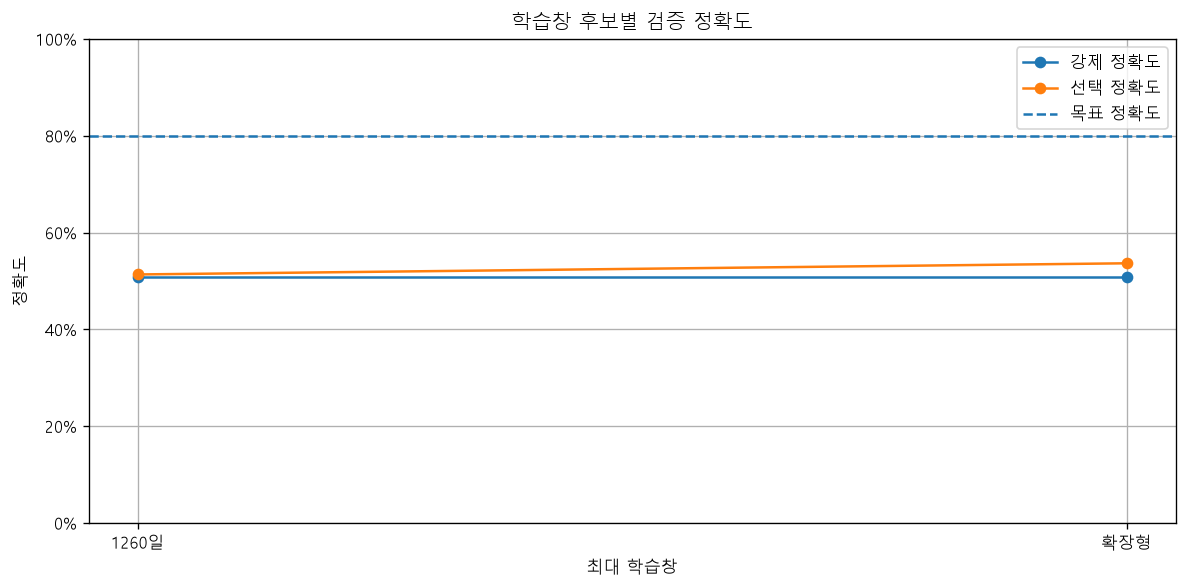

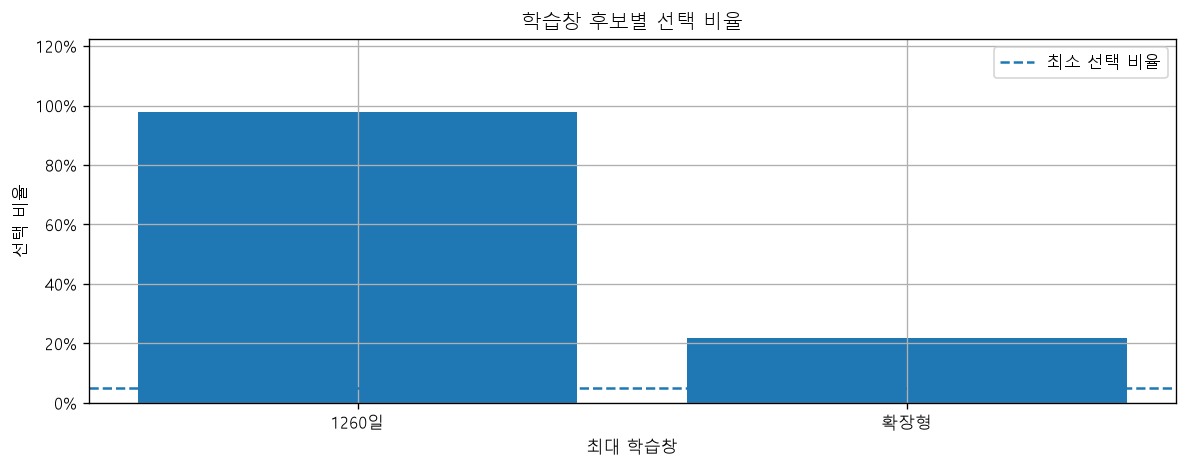

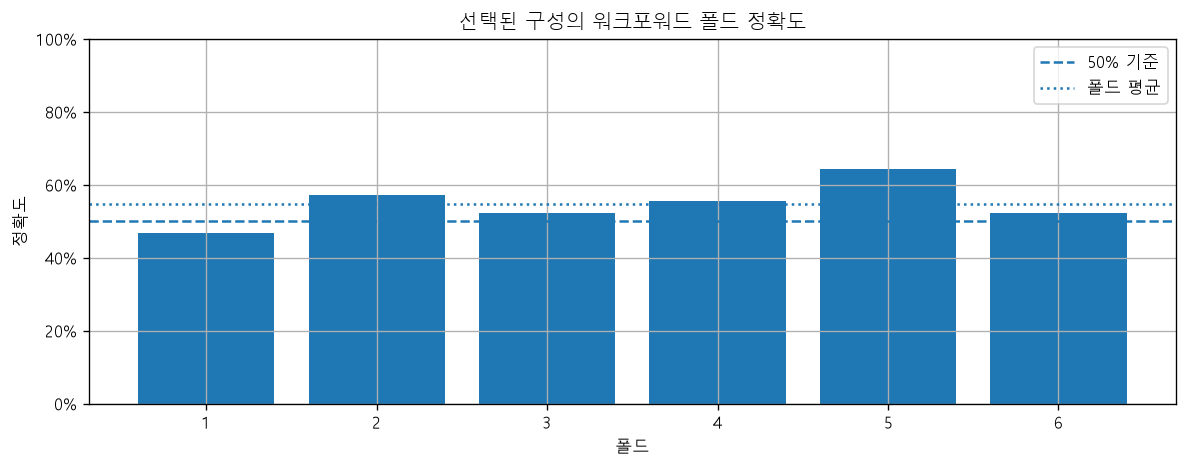

In [21]:
visual_research = research_table.copy()
visual_research["학습창"] = visual_research["max_train_days"].apply(
    lambda value: "확장형" if pd.isna(value) else f"{int(value)}일"
)

plt.figure(figsize=(10, 5))
plt.plot(visual_research["학습창"], visual_research["forced_accuracy"], marker="o", label="강제 정확도")
plt.plot(visual_research["학습창"], visual_research["accuracy"], marker="o", label="선택 정확도")
plt.axhline(config.target_accuracy, linestyle="--", label="목표 정확도")
plt.title("학습창 후보별 검증 정확도")
plt.xlabel("최대 학습창")
plt.ylabel("정확도")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("08_training_window_accuracy.png")

plt.figure(figsize=(10, 4))
plt.bar(visual_research["학습창"], visual_research["coverage"])
plt.axhline(config.min_coverage, linestyle="--", label="최소 선택 비율")
plt.title("학습창 후보별 선택 비율")
plt.xlabel("최대 학습창")
plt.ylabel("선택 비율")
plt.ylim(0, max(0.2, float(visual_research["coverage"].max()) * 1.25))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("09_training_window_coverage.png")

fold_table = pd.DataFrame(best_components["fold_records"])

if not fold_table.empty:
    plt.figure(figsize=(10, 4))
    plt.bar(fold_table["fold"].astype(str), fold_table["accuracy"])
    plt.axhline(0.5, linestyle="--", label="50% 기준")
    plt.axhline(fold_table["accuracy"].mean(), linestyle=":", label="폴드 평균")
    plt.title("선택된 구성의 워크포워드 폴드 정확도")
    plt.xlabel("폴드")
    plt.ylabel("정확도")
    plt.ylim(0, 1)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.legend()
    finish_figure("10_walk_forward_fold_accuracy.png")

## 12. 손대지 않은 최종 테스트와 최신 예측

최종 테스트에서는 일정 간격으로 과거 데이터만 다시 학습해 다음 블록을 예측합니다. 테스트 정답은 모델 선택이나 임계값 선택에 사용하지 않습니다.

`passed_80` 조건:

- 선택 정확도 80% 이상
- 최소 테스트 신호 수 충족
- 최소 선택 비율 충족
- 상승·하락 양쪽 최소 신호 수 충족

`certified_80` 조건:

- `passed_80`이 참
- 선택 정확도 신뢰구간 하한도 80% 이상

최신 방향은 `certified_80`을 통과하고 오늘 선택 점수가 임계값 이상일 때만 출력됩니다.

In [22]:
def predict_with_models(models: dict[str, Pipeline], x: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {f"prob_{name}": model.predict_proba(x)[:, 1] for name, model in models.items()},
        index=x.index,
    )

def walk_forward_test(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    development_dates: pd.DatetimeIndex,
    test_dates: pd.DatetimeIndex,
    max_train_days: int | None,
    stacker: Pipeline,
    selector: Pipeline,
    selector_columns: list[str],
    selection_threshold: float,
    config: ResearchConfig,
) -> tuple[pd.DataFrame, dict[str, Pipeline]]:
    model_templates = build_models(config.mode, config.random_state)
    target_predictions: list[pd.DataFrame] = []
    last_fitted: dict[str, Pipeline] = {}
    for block_start in range(0, len(test_dates), config.refit_days):
        block_dates = test_dates[block_start : block_start + config.refit_days]
        first_test_date = block_dates[0]
        available_dates = pd.DatetimeIndex(sorted(pd.unique(dataset.loc[dataset["date"] < first_test_date, "date"])))
        if config.gap_days > 0:
            available_dates = available_dates[: -config.gap_days] if len(available_dates) > config.gap_days else pd.DatetimeIndex([])
        if max_train_days is not None and len(available_dates) > max_train_days:
            available_dates = available_dates[-max_train_days:]
        train = dataset[dataset["date"].isin(available_dates) & dataset["target"].notna()]
        test_block = dataset[
            dataset["date"].isin(block_dates)
            & dataset["target"].notna()
            & (dataset["ticker"] == config.ticker)
        ].copy()
        if train.empty or test_block.empty:
            continue
        print(
            f"테스트 재학습 {block_dates[0].date()}~{block_dates[-1].date()} "
            f"학습종료={available_dates[-1].date()}"
        )
        last_fitted, raw_probabilities = fit_predict_models(
            model_templates,
            train[feature_columns],
            train["target"].astype(int),
            test_block[feature_columns],
        )
        raw_probabilities.columns = [f"prob_{column}" for column in raw_probabilities.columns]
        stacked_probability = apply_stacker(stacker, raw_probabilities)
        selector_x = build_selector_features(
            test_block.reset_index(drop=True),
            raw_probabilities.reset_index(drop=True),
            stacked_probability,
            selector_columns,
        )
        selection_score = selector.predict_proba(selector_x)[:, 1]
        output = test_block[["date", "ticker", "target", "future_return", "close_price"]].copy()
        output["direction_probability"] = stacked_probability
        output["selection_score"] = selection_score
        output["prediction"] = (stacked_probability >= 0.5).astype(int)
        output["selected"] = selection_score >= selection_threshold
        output["correct"] = output["prediction"] == output["target"].astype(int)
        target_predictions.append(output)
    if not target_predictions:
        raise RuntimeError("테스트 예측을 생성하지 못했습니다.")
    return pd.concat(target_predictions).sort_values("date"), last_fitted

def summarize_test(predictions: pd.DataFrame, config: ResearchConfig) -> dict[str, Any]:
    y_true = predictions["target"].astype(int).to_numpy()
    y_pred = predictions["prediction"].astype(int).to_numpy()
    probability = predictions["direction_probability"].to_numpy()
    selected = predictions["selected"].to_numpy(dtype=bool)
    majority = int(np.mean(y_true) >= 0.5)
    majority_accuracy = float(np.mean(y_true == majority))
    summary: dict[str, Any] = {
        "test_start": str(predictions["date"].min().date()),
        "test_end": str(predictions["date"].max().date()),
        "test_samples": int(len(predictions)),
        "forced_accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "majority_baseline": majority_accuracy,
        "roc_auc": float(roc_auc_score(y_true, probability)) if len(np.unique(y_true)) > 1 else math.nan,
        "brier": float(brier_score_loss(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "signals": int(selected.sum()),
        "coverage": float(selected.mean()),
    }
    if selected.any():
        selected_y = y_true[selected]
        selected_prediction = y_pred[selected]
        successes = int((selected_y == selected_prediction).sum())
        total = int(selected.sum())
        lower, upper = clopper_pearson_interval(successes, total, config.confidence_level)
        summary.update(
            {
                "selective_accuracy": float(successes / total),
                "selective_lower": lower,
                "selective_upper": upper,
                "up_signals": int((selected_prediction == 1).sum()),
                "down_signals": int((selected_prediction == 0).sum()),
            }
        )
    else:
        summary.update(
            {
                "selective_accuracy": math.nan,
                "selective_lower": math.nan,
                "selective_upper": math.nan,
                "up_signals": 0,
                "down_signals": 0,
            }
        )
    summary["passed_80"] = bool(
        summary["signals"] >= config.min_test_signals
        and summary["coverage"] >= config.min_coverage
        and np.isfinite(summary["selective_accuracy"])
        and summary["selective_accuracy"] >= config.target_accuracy
        and summary["up_signals"] >= config.min_side_signals
        and summary["down_signals"] >= config.min_side_signals
    )
    summary["certified_80"] = bool(
        summary["passed_80"]
        and np.isfinite(summary["selective_lower"])
        and summary["selective_lower"] >= config.target_accuracy
    )
    return summary

def fit_production_models(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    max_train_days: int | None,
    config: ResearchConfig,
) -> dict[str, Pipeline]:
    labeled_dates = pd.DatetimeIndex(sorted(pd.unique(dataset.loc[dataset["target"].notna(), "date"])))
    if max_train_days is not None and len(labeled_dates) > max_train_days:
        labeled_dates = labeled_dates[-max_train_days:]
    train = dataset[dataset["date"].isin(labeled_dates) & dataset["target"].notna()]
    models = build_models(config.mode, config.random_state)
    fitted, _ = fit_predict_models(
        models,
        train[feature_columns],
        train["target"].astype(int),
        train[feature_columns].iloc[:1],
    )
    return fitted

def latest_prediction(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    fitted_models: dict[str, Pipeline],
    stacker: Pipeline,
    selector: Any,
    selector_columns: list[str],
    threshold: float,
    config: ResearchConfig,
    allow_signal: bool,
) -> dict[str, Any]:
    latest_candidates = dataset[(dataset["ticker"] == config.ticker) & dataset["is_latest"]].sort_values("date")
    if latest_candidates.empty:
        latest_candidates = dataset[dataset["ticker"] == config.ticker].sort_values("date").tail(1)
    latest = latest_candidates.tail(1)
    raw = predict_with_models(fitted_models, latest[feature_columns])
    probability = float(apply_stacker(stacker, raw)[0])
    selector_x = build_selector_features(
        latest.reset_index(drop=True),
        raw.reset_index(drop=True),
        np.array([probability]),
        selector_columns,
    )
    selection_score = float(selector.predict_proba(selector_x)[0, 1])
    model_selected = selection_score >= threshold
    selected = model_selected and allow_signal
    direction = "상승" if probability >= 0.5 else "하락"
    return {
        "date": str(latest["date"].iloc[0].date()),
        "close": float(latest["close_price"].iloc[0]),
        "direction_probability_up": probability,
        "direction": direction,
        "selection_score": selection_score,
        "model_selected": bool(model_selected),
        "selected": bool(selected),
        "decision": direction if selected else "관망",
    }

def save_outputs(
    output_dir: Path,
    config: ResearchConfig,
    dataset: pd.DataFrame,
    feature_columns: list[str],
    research_table: pd.DataFrame,
    best_summary: dict[str, Any],
    best_components: dict[str, Any],
    test_predictions: pd.DataFrame,
    test_summary: dict[str, Any],
    latest: dict[str, Any],
    production_models: dict[str, Pipeline],
    failures: dict[str, str],
) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    research_table.to_csv(output_dir / "configuration_results.csv", index=False, encoding="utf-8-sig")
    best_components["oof"].to_csv(output_dir / "oof_predictions.csv", index=False, encoding="utf-8-sig")
    best_components["risk_coverage"].to_csv(output_dir / "calibration_risk_coverage.csv", index=False, encoding="utf-8-sig")
    test_predictions.to_csv(output_dir / "test_predictions.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(best_components["fold_records"]).to_csv(output_dir / "fold_results.csv", index=False, encoding="utf-8-sig")
    metadata = {
        "config": asdict(config),
        "best_configuration": best_summary,
        "test": test_summary,
        "latest": latest,
        "feature_count": len(feature_columns),
        "dataset_rows": int(len(dataset)),
        "download_failures": failures,
    }
    with (output_dir / "summary.json").open("w", encoding="utf-8") as file:
        json.dump(metadata, file, ensure_ascii=False, indent=2, allow_nan=True)
    bundle = {
        "config": asdict(config),
        "feature_columns": feature_columns,
        "max_train_days": best_summary["max_train_days"],
        "selection_threshold": best_summary["threshold"],
        "stacker": best_components["stacker"],
        "selector": best_components["selector"],
        "selector_columns": best_components["selector_columns"],
        "models": production_models,
        "test_summary": test_summary,
    }
    joblib.dump(bundle, output_dir / "model_bundle.joblib")

def print_summary(
    config: ResearchConfig,
    best_summary: dict[str, Any],
    test_summary: dict[str, Any],
    latest: dict[str, Any],
    output_dir: Path,
) -> None:
    print()
    print("=" * 72)
    print("80% 목표 주가 방향 예측 연구 결과")
    print("=" * 72)
    print(f"종목: {config.ticker}")
    print(f"선택된 학습창: {best_summary['max_train_days'] or '확장형'} 거래일")
    print(f"검증 선택 방식: {best_summary['selection_status']}")
    print(f"검증 강제 적중률: {best_summary['forced_accuracy'] * 100:.2f}%")
    print(f"검증 선택 적중률: {best_summary['accuracy'] * 100:.2f}%")
    print(f"검증 선택 비율: {best_summary['coverage'] * 100:.2f}%")
    print(f"선택 임계값: {best_summary['threshold']:.4f}")
    print("-" * 72)
    print(f"테스트 기간: {test_summary['test_start']} ~ {test_summary['test_end']}")
    print(f"테스트 강제 적중률: {test_summary['forced_accuracy'] * 100:.2f}%")
    print(f"다수 클래스 기준선: {test_summary['majority_baseline'] * 100:.2f}%")
    print(f"테스트 선택 적중률: {test_summary['selective_accuracy'] * 100:.2f}%" if np.isfinite(test_summary['selective_accuracy']) else "테스트 선택 적중률: 신호 없음")
    print(f"테스트 선택 비율: {test_summary['coverage'] * 100:.2f}%")
    print(f"테스트 선택 신호 수: {test_summary['signals']}")
    if np.isfinite(test_summary["selective_lower"]):
        print(
            f"선택 적중률 {config.confidence_level * 100:.0f}% 구간: "
            f"{test_summary['selective_lower'] * 100:.2f}% ~ {test_summary['selective_upper'] * 100:.2f}%"
        )
    print(f"80% 독립 테스트 통과: {'예' if test_summary['passed_80'] else '아니오'}")
    print(f"80% 신뢰구간 인증: {'예' if test_summary['certified_80'] else '아니오'}")
    print("-" * 72)
    print(f"최신 데이터 날짜: {latest['date']}")
    print(f"최근 종가: {latest['close']:,.2f}")
    print(f"상승 확률: {latest['direction_probability_up'] * 100:.2f}%")
    print(f"선택 점수: {latest['selection_score'] * 100:.2f}%")
    print(f"최종 판단: {latest['decision']}")
    if not test_summary["passed_80"]:
        print("상태: 80%가 미검증되어 실전 배포 금지")
    elif not test_summary["certified_80"]:
        print("상태: 점추정 80%는 통과했지만 통계 인증 전이므로 관망 고정")
    elif not latest["selected"]:
        print("상태: 모델은 검증을 통과했지만 오늘은 저신뢰 구간")
    else:
        print("상태: 80% 신뢰구간 인증을 통과한 고신뢰 신호")
    print(f"결과 폴더: {output_dir.resolve()}")
    print("=" * 72)

In [23]:
test_predictions, _ = walk_forward_test(
    dataset,
    feature_columns,
    development_dates,
    test_dates,
    best_summary["max_train_days"],
    best_components["stacker"],
    best_components["selector"],
    best_components["selector_columns"],
    best_summary["threshold"],
    config,
)

test_summary = summarize_test(test_predictions, config)

production_models = fit_production_models(
    dataset,
    feature_columns,
    best_summary["max_train_days"],
    config,
)

latest = latest_prediction(
    dataset,
    feature_columns,
    production_models,
    best_components["stacker"],
    best_components["selector"],
    best_components["selector_columns"],
    best_summary["threshold"],
    config,
    test_summary["certified_80"],
)

output_dir = Path(config.output_dir)

save_outputs(
    output_dir,
    config,
    dataset,
    feature_columns,
    research_table,
    best_summary,
    best_components,
    test_predictions,
    test_summary,
    latest,
    production_models,
    failures,
)

print_summary(
    config,
    best_summary,
    test_summary,
    latest,
    output_dir,
)

테스트 재학습 2025-08-08~2025-09-08 학습종료=2025-08-06
테스트 재학습 2025-09-09~2025-10-14 학습종료=2025-09-05
테스트 재학습 2025-10-15~2025-11-12 학습종료=2025-10-13
테스트 재학습 2025-11-13~2025-12-11 학습종료=2025-11-11
테스트 재학습 2025-12-12~2026-01-14 학습종료=2025-12-10
테스트 재학습 2026-01-15~2026-02-12 학습종료=2026-01-13
테스트 재학습 2026-02-13~2026-03-19 학습종료=2026-02-11
테스트 재학습 2026-03-20~2026-04-17 학습종료=2026-03-18
테스트 재학습 2026-04-20~2026-05-20 학습종료=2026-04-16
테스트 재학습 2026-05-21~2026-06-22 학습종료=2026-05-19
테스트 재학습 2026-06-23~2026-07-22 학습종료=2026-06-19
테스트 재학습 2026-07-23~2026-08-21 학습종료=2026-07-21

80% 목표 주가 방향 예측 연구 결과
종목: 000660.KS
선택된 학습창: 1260 거래일
검증 선택 방식: target_not_found
검증 강제 적중률: 50.79%
검증 선택 적중률: 51.35%
검증 선택 비율: 97.88%
선택 임계값: 0.3224
------------------------------------------------------------------------
테스트 기간: 2025-08-08 ~ 2026-08-21
테스트 강제 적중률: 46.03%
다수 클래스 기준선: 57.94%
테스트 선택 적중률: 46.00%
테스트 선택 비율: 99.21%
테스트 선택 신호 수: 250
선택 적중률 90% 구간: 40.67% ~ 51.40%
80% 독립 테스트 통과: 아니오
80% 신뢰구간 인증: 아니오
----------------------------------

## 13. 결과 표와 시각화 대시보드

정확도 하나만 보지 않고 기준선, 선택 비율, 신호 수, 혼동행렬, 확률 보정, 시기별 안정성, 선택 신호 위치와 특징 중요도를 함께 확인합니다. 모든 그래프는 `OUTPUT_DIR/figures`에 저장됩니다.

,지표,값
0,강제 정확도,0.460317
1,균형 정확도,0.457999
2,다수 클래스 기준선,0.579365
3,ROC AUC,0.472021
4,Brier score,0.251286
5,선택 정확도,0.46
6,선택 비율,0.992063
7,선택 신호 수,250
8,90% 신뢰구간 하한,0.406717
9,90% 신뢰구간 상한,0.513997


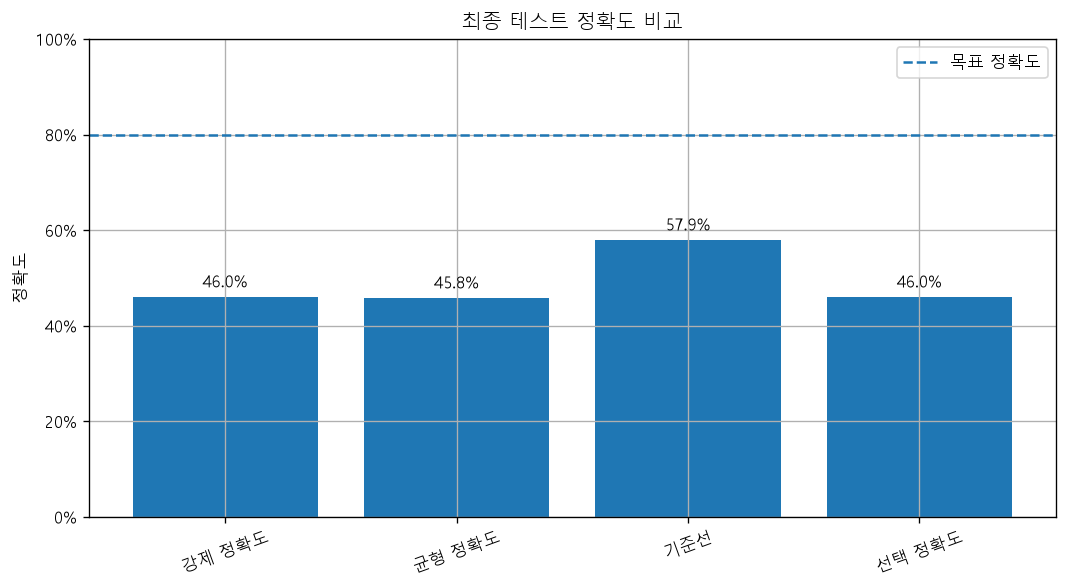

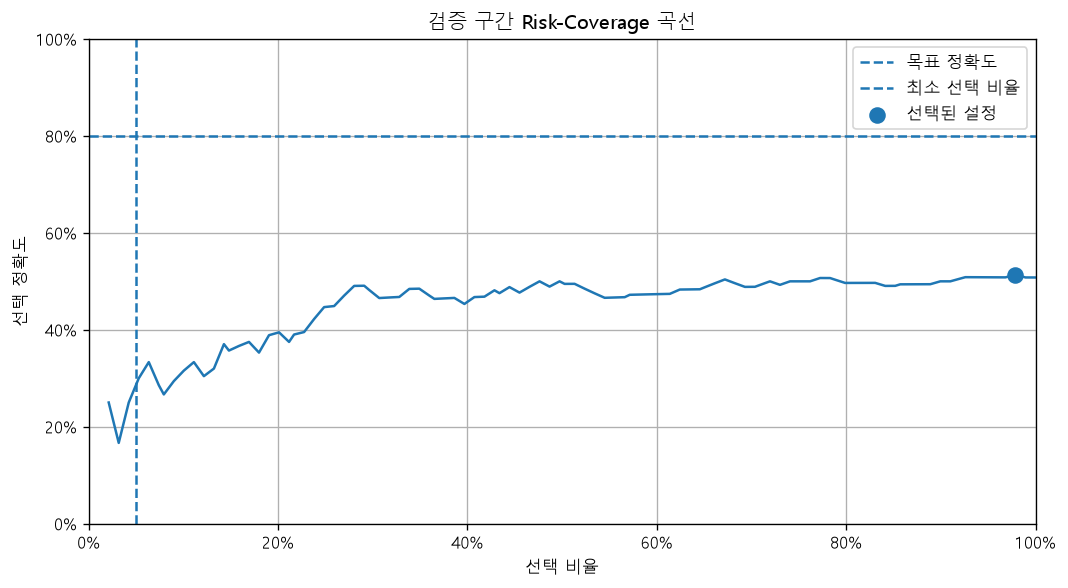

In [24]:
test_result_table = pd.DataFrame(
    {
        "지표": [
            "강제 정확도",
            "균형 정확도",
            "다수 클래스 기준선",
            "ROC AUC",
            "Brier score",
            "선택 정확도",
            "선택 비율",
            "선택 신호 수",
            f"{config.confidence_level * 100:.0f}% 신뢰구간 하한",
            f"{config.confidence_level * 100:.0f}% 신뢰구간 상한",
            "80% 테스트 통과",
            "80% 통계 인증",
        ],
        "값": [
            test_summary["forced_accuracy"],
            test_summary["balanced_accuracy"],
            test_summary["majority_baseline"],
            test_summary["roc_auc"],
            test_summary["brier"],
            test_summary["selective_accuracy"],
            test_summary["coverage"],
            test_summary["signals"],
            test_summary["selective_lower"],
            test_summary["selective_upper"],
            test_summary["passed_80"],
            test_summary["certified_80"],
        ],
    }
)

display(test_result_table)

accuracy_metrics = pd.Series(
    {
        "강제 정확도": test_summary["forced_accuracy"],
        "균형 정확도": test_summary["balanced_accuracy"],
        "기준선": test_summary["majority_baseline"],
        "선택 정확도": test_summary["selective_accuracy"],
    }
).dropna()

plt.figure(figsize=(9, 5))
plt.bar(accuracy_metrics.index, accuracy_metrics.values)
plt.axhline(config.target_accuracy, linestyle="--", label="목표 정확도")
plt.title("최종 테스트 정확도 비교")
plt.ylabel("정확도")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
for position, value in enumerate(accuracy_metrics.values):
    plt.text(position, value + 0.02, f"{value:.1%}", ha="center")
plt.legend()
finish_figure("11_test_accuracy_summary.png")

risk_coverage = best_components["risk_coverage"].copy()
risk_coverage = risk_coverage.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["coverage", "accuracy"]
).sort_values("coverage")

plt.figure(figsize=(9, 5))
plt.plot(risk_coverage["coverage"], risk_coverage["accuracy"])
plt.axhline(config.target_accuracy, linestyle="--", label="목표 정확도")
plt.axvline(config.min_coverage, linestyle="--", label="최소 선택 비율")
plt.scatter([best_summary["coverage"]], [best_summary["accuracy"]], s=80, label="선택된 설정")
plt.title("검증 구간 Risk-Coverage 곡선")
plt.xlabel("선택 비율")
plt.ylabel("선택 정확도")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("12_risk_coverage_curve.png")

### 13-1. 예측 오류와 확률 품질

혼동행렬은 상승·하락을 각각 얼마나 맞혔는지 보여 줍니다. 확률 시계열과 분포는 모델이 어느 정도 확신했는지, 보정 곡선은 예측 확률과 실제 상승 빈도가 비슷한지 보여 줍니다.

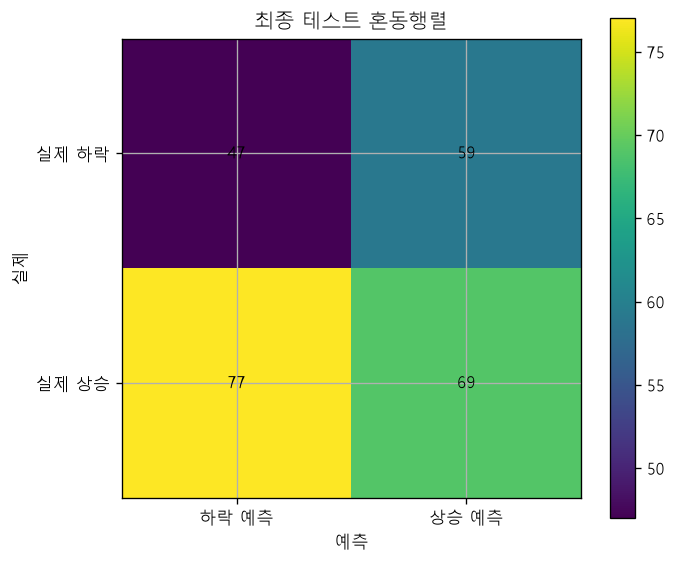

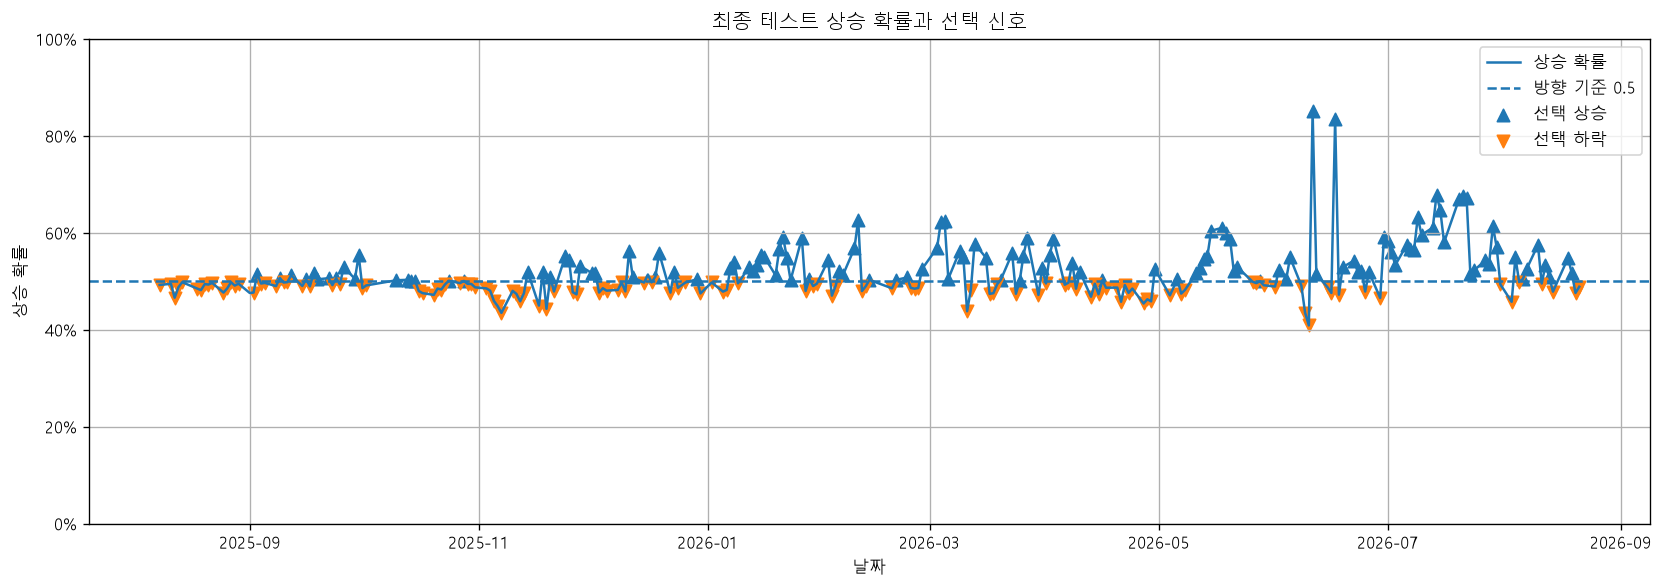

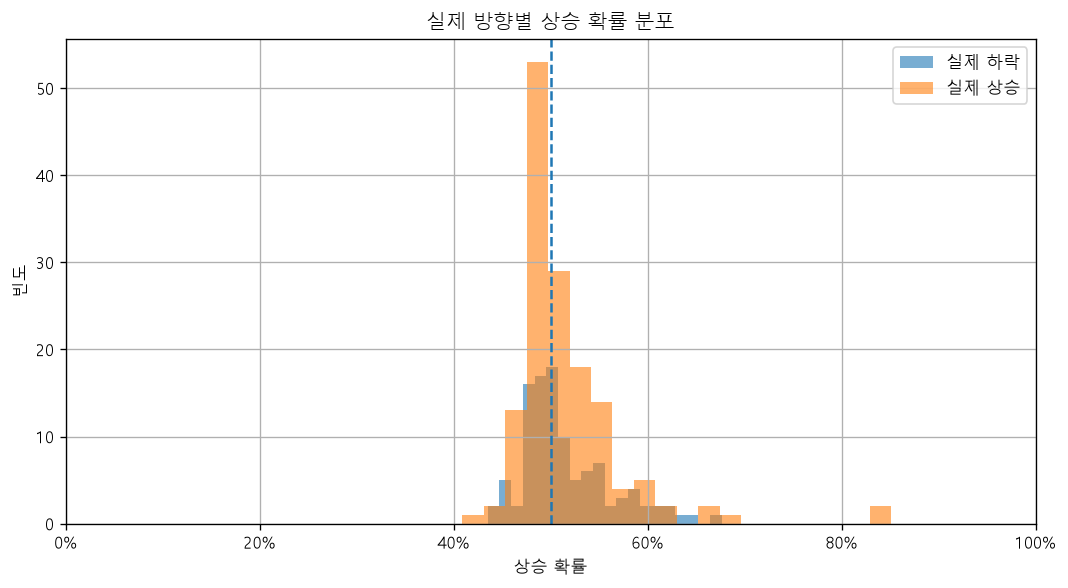

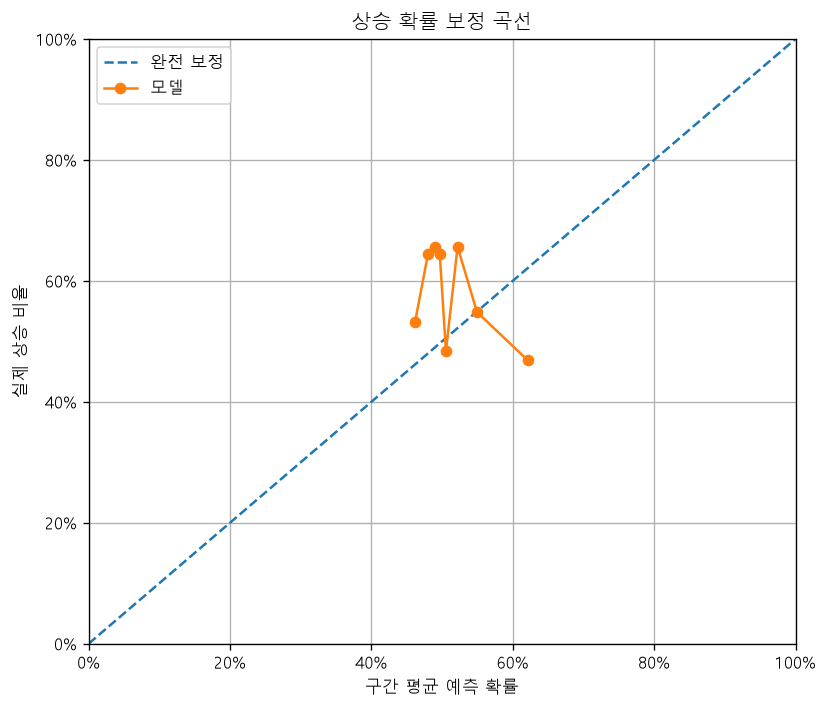

In [25]:
ordered_test = test_predictions.sort_values("date").reset_index(drop=True).copy()
y_true = ordered_test["target"].astype(int)
y_pred = ordered_test["prediction"].astype(int)
probability = ordered_test["direction_probability"].astype(float)

matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(matrix)
axis.set_xticks([0, 1], labels=["하락 예측", "상승 예측"])
axis.set_yticks([0, 1], labels=["실제 하락", "실제 상승"])
axis.set_xlabel("예측")
axis.set_ylabel("실제")
axis.set_title("최종 테스트 혼동행렬")
for row in range(2):
    for column in range(2):
        axis.text(column, row, str(matrix[row, column]), ha="center", va="center")
figure.colorbar(image, ax=axis)
finish_figure("13_confusion_matrix.png")

plt.figure(figsize=(14, 5))
plt.plot(ordered_test["date"], probability, label="상승 확률")
plt.axhline(0.5, linestyle="--", label="방향 기준 0.5")
selected_up = ordered_test[ordered_test["selected"] & (ordered_test["prediction"] == 1)]
selected_down = ordered_test[ordered_test["selected"] & (ordered_test["prediction"] == 0)]
plt.scatter(selected_up["date"], selected_up["direction_probability"], marker="^", s=55, label="선택 상승")
plt.scatter(selected_down["date"], selected_down["direction_probability"], marker="v", s=55, label="선택 하락")
plt.title("최종 테스트 상승 확률과 선택 신호")
plt.xlabel("날짜")
plt.ylabel("상승 확률")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("14_probability_timeline.png")

plt.figure(figsize=(9, 5))
plt.hist(probability[y_true == 0], bins=20, alpha=0.6, label="실제 하락")
plt.hist(probability[y_true == 1], bins=20, alpha=0.6, label="실제 상승")
plt.axvline(0.5, linestyle="--")
plt.title("실제 방향별 상승 확률 분포")
plt.xlabel("상승 확률")
plt.ylabel("빈도")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("15_probability_distribution.png")

observed_frequency, mean_prediction = calibration_curve(
    y_true,
    probability,
    n_bins=min(10, max(3, len(ordered_test) // 30)),
    strategy="quantile",
)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="완전 보정")
plt.plot(mean_prediction, observed_frequency, marker="o", label="모델")
plt.title("상승 확률 보정 곡선")
plt.xlabel("구간 평균 예측 확률")
plt.ylabel("실제 상승 비율")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("16_calibration_curve.png")

### 13-2. 시기별 안정성과 선택 신호

이동 정확도와 월별 정확도는 특정 시기에만 성능이 높았는지 확인합니다. 가격 위의 삼각형은 메타 선택기가 고른 상승·하락 신호이고, 선택 신호 누적 정확도는 신호가 쌓일수록 목표 수준이 유지되는지 보여 줍니다.

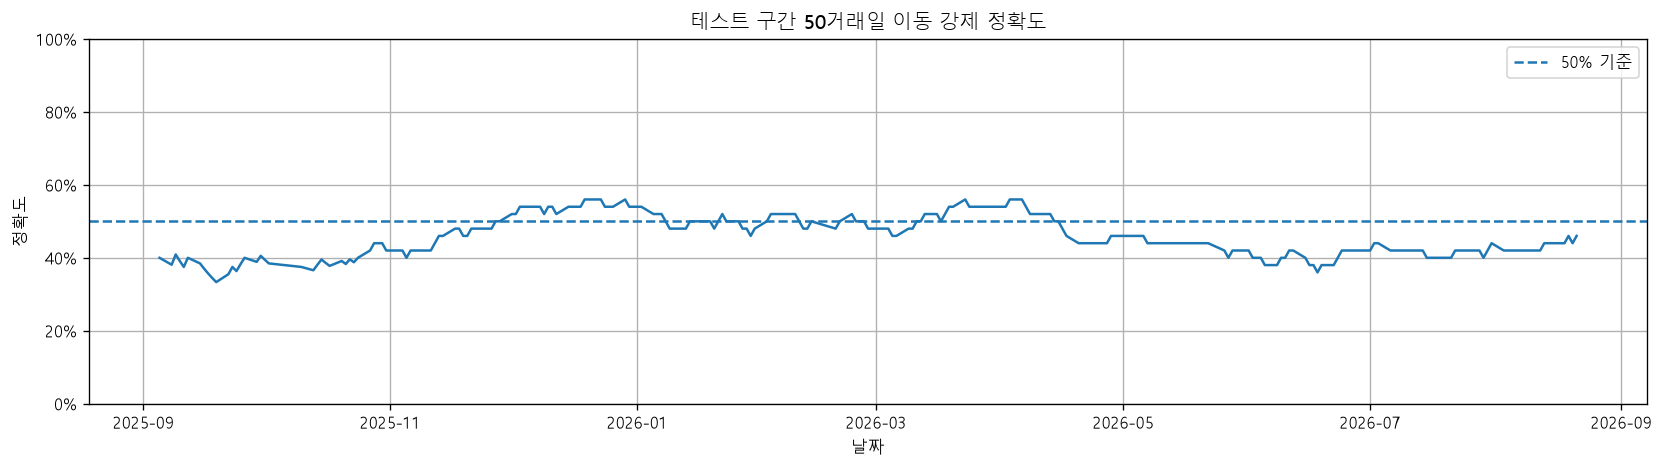

,강제 정확도,선택 정확도
month,,
2025-09,0.363636,0.380952
2025-10,0.444444,0.444444
2025-11,0.600000,0.600000
2025-12,0.476190,0.450000
2026-01,0.476190,0.476190
2026-02,0.529412,0.529412
2026-03,0.523810,0.523810
2026-04,0.409091,0.409091
2026-05,0.388889,0.388889


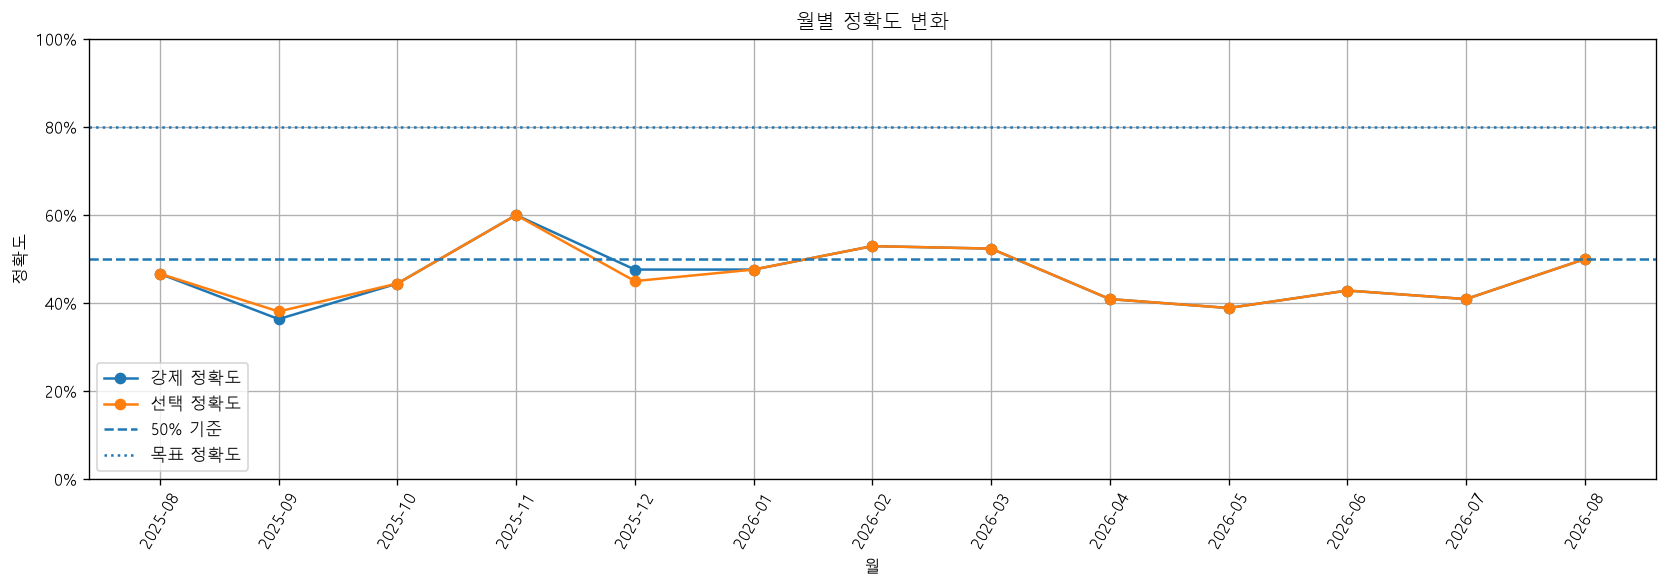

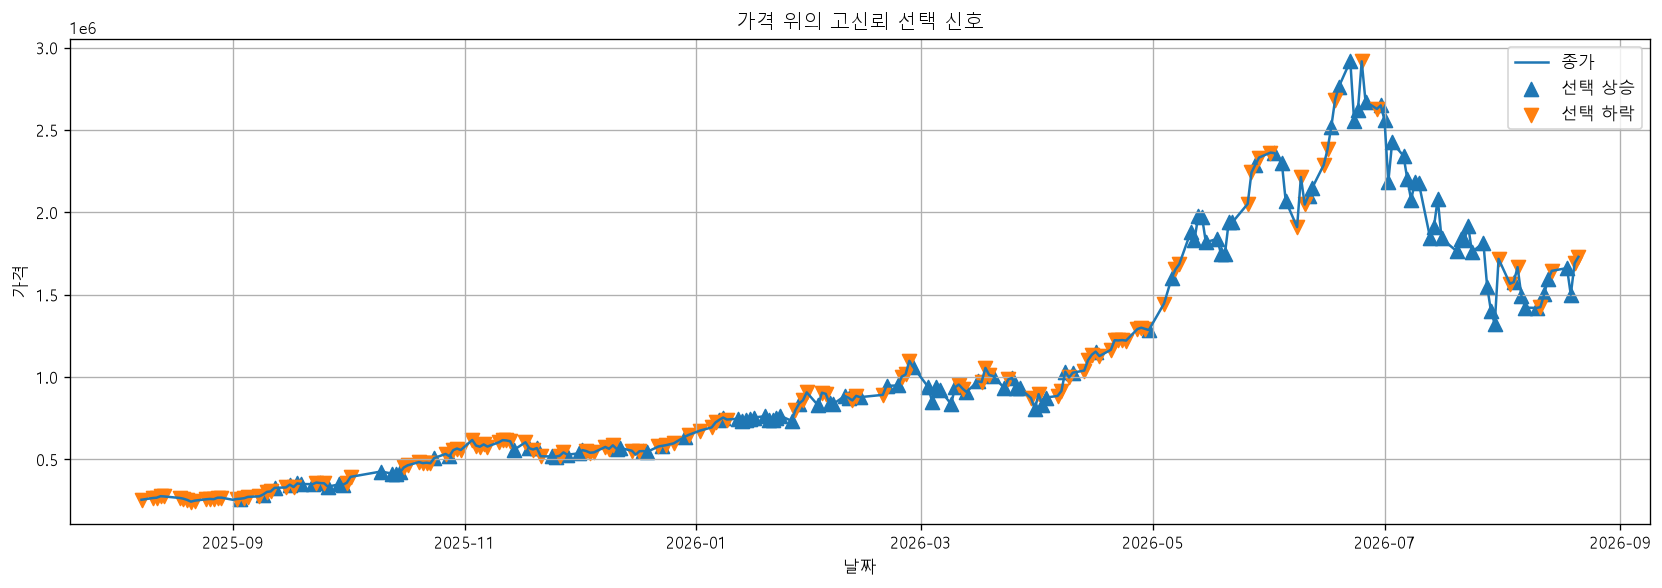

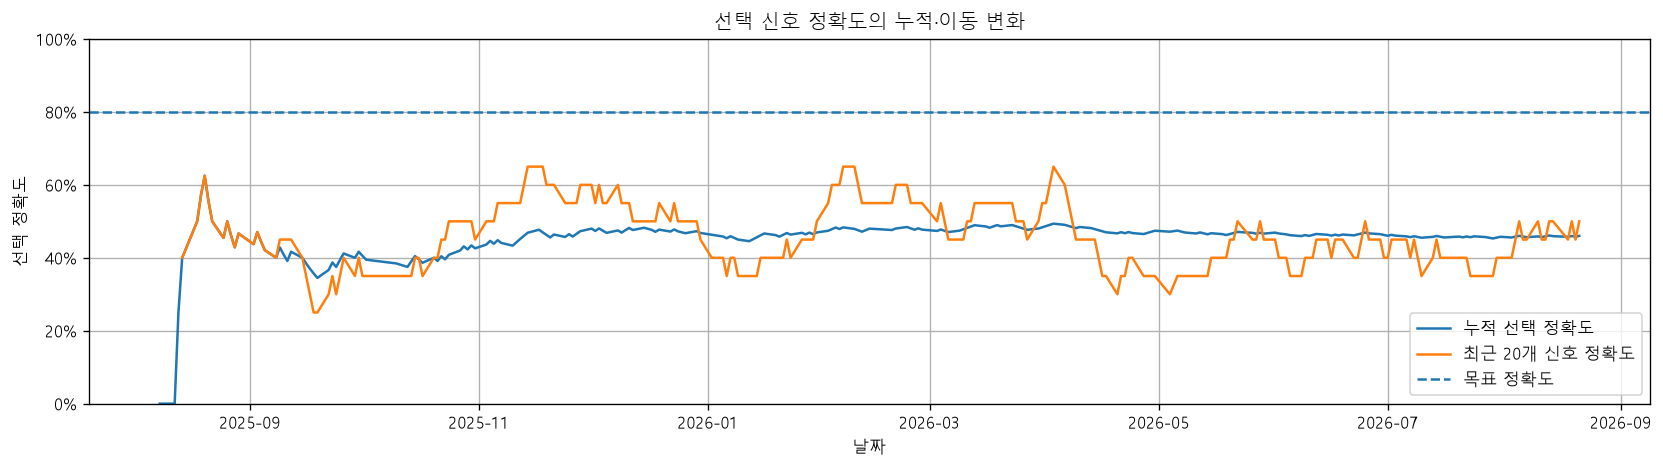

In [26]:
ordered_test["rolling_forced_accuracy"] = ordered_test["correct"].rolling(50, min_periods=20).mean()

plt.figure(figsize=(14, 4))
plt.plot(ordered_test["date"], ordered_test["rolling_forced_accuracy"])
plt.axhline(0.5, linestyle="--", label="50% 기준")
plt.title("테스트 구간 50거래일 이동 강제 정확도")
plt.xlabel("날짜")
plt.ylabel("정확도")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("17_rolling_forced_accuracy.png")

ordered_test["month"] = pd.to_datetime(ordered_test["date"]).dt.to_period("M").astype(str)
monthly_forced = ordered_test.groupby("month")["correct"].mean()
monthly_selected = ordered_test[ordered_test["selected"]].groupby("month")["correct"].mean()
monthly_table = pd.concat(
    [monthly_forced.rename("강제 정확도"), monthly_selected.rename("선택 정확도")],
    axis=1,
)

display(monthly_table.tail(12))

plt.figure(figsize=(14, 5))
plt.plot(monthly_table.index, monthly_table["강제 정확도"], marker="o", label="강제 정확도")
plt.plot(monthly_table.index, monthly_table["선택 정확도"], marker="o", label="선택 정확도")
plt.axhline(0.5, linestyle="--", label="50% 기준")
plt.axhline(config.target_accuracy, linestyle=":", label="목표 정확도")
plt.title("월별 정확도 변화")
plt.xlabel("월")
plt.ylabel("정확도")
plt.ylim(0, 1)
plt.xticks(rotation=60)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
finish_figure("18_monthly_accuracy.png")

plt.figure(figsize=(14, 5))
plt.plot(ordered_test["date"], ordered_test["close_price"], label="종가")
plt.scatter(selected_up["date"], selected_up["close_price"], marker="^", s=70, label="선택 상승")
plt.scatter(selected_down["date"], selected_down["close_price"], marker="v", s=70, label="선택 하락")
plt.title("가격 위의 고신뢰 선택 신호")
plt.xlabel("날짜")
plt.ylabel("가격")
plt.legend()
finish_figure("19_selected_signals_on_price.png")

selected_test = ordered_test[ordered_test["selected"]].copy()

if not selected_test.empty:
    selected_test["cumulative_selective_accuracy"] = selected_test["correct"].expanding().mean()
    selected_test["rolling_selective_accuracy"] = selected_test["correct"].rolling(20, min_periods=5).mean()

    plt.figure(figsize=(14, 4))
    plt.plot(selected_test["date"], selected_test["cumulative_selective_accuracy"], label="누적 선택 정확도")
    plt.plot(selected_test["date"], selected_test["rolling_selective_accuracy"], label="최근 20개 신호 정확도")
    plt.axhline(config.target_accuracy, linestyle="--", label="목표 정확도")
    plt.title("선택 신호 정확도의 누적·이동 변화")
    plt.xlabel("날짜")
    plt.ylabel("선택 정확도")
    plt.ylim(0, 1)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.legend()
    finish_figure("20_selective_accuracy_stability.png")
else:
    print("선택된 테스트 신호가 없어 선택 정확도 그래프를 생략합니다.")

### 13-3. 모델 특징 중요도

선형 모델의 절대 계수와 트리 모델의 중요도를 각각 정규화한 뒤 평균냅니다. 이는 인과관계를 증명하는 값이 아니라, 현재 학습된 모델이 어떤 입력을 상대적으로 많이 활용했는지 살펴보는 설명용 지표입니다.

,feature,importance
46,context_qqq_volatility_20,0.017560
59,context_sox_trend_5,0.013943
74,context_spy_trend_5,0.013740
61,context_sox_volatility_20,0.013627
88,context_usdkrw_trend_20,0.013583
5,context_kosdaq_drawdown_5,0.012307
21,context_kospi_drawdown_60,0.012163
79,context_usdkrw_drawdown_20,0.011971
90,context_usdkrw_trend_60,0.011301
97,context_vix_return_1,0.011154


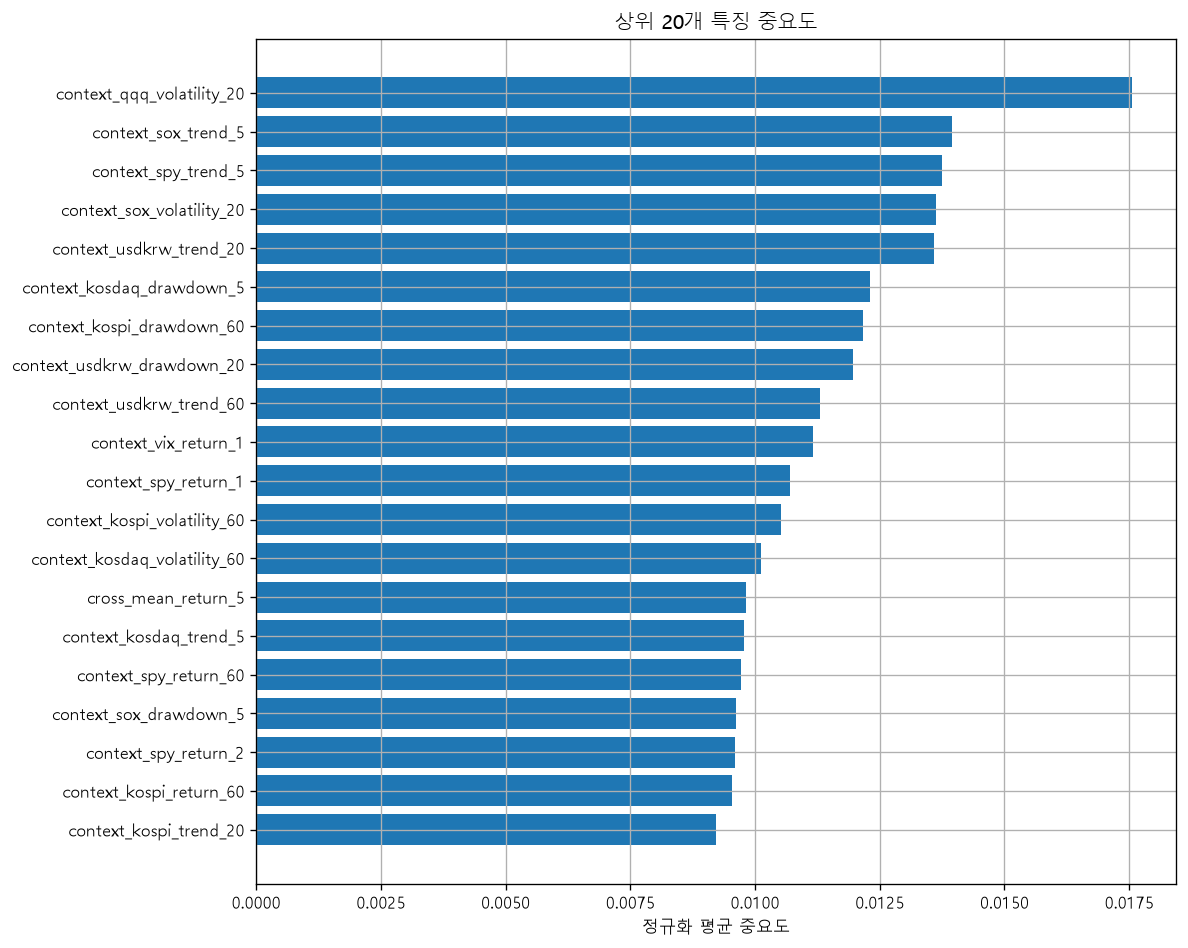

In [27]:
def aggregate_feature_importance(
    models: dict[str, Pipeline],
    feature_columns: list[str],
) -> pd.DataFrame:
    records = []
    feature_count = len(feature_columns)

    for model_name, pipeline in models.items():
        estimator = pipeline.named_steps.get("model")
        values = None

        if hasattr(estimator, "feature_importances_"):
            values = np.asarray(estimator.feature_importances_, dtype=float)
        elif hasattr(estimator, "coef_"):
            values = np.abs(np.asarray(estimator.coef_, dtype=float)).mean(axis=0)

        if values is None or len(values) < feature_count:
            continue

        values = values[:feature_count]
        total = values.sum()

        if not np.isfinite(total) or total <= 0:
            continue

        normalized = values / total

        records.append(
            pd.DataFrame(
                {
                    "feature": feature_columns,
                    "importance": normalized,
                    "model": model_name,
                }
            )
        )

    if not records:
        return pd.DataFrame(columns=["feature", "importance"])

    return (
        pd.concat(records, ignore_index=True)
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
    )


feature_importance = aggregate_feature_importance(production_models, feature_columns)
top_importance = feature_importance.head(20).sort_values("importance")

if not top_importance.empty:
    display(feature_importance.head(20))

    plt.figure(figsize=(10, 8))
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.title("상위 20개 특징 중요도")
    plt.xlabel("정규화 평균 중요도")
    finish_figure("21_feature_importance.png")
else:
    print("현재 모델에서 직접 추출 가능한 특징 중요도가 없습니다.")

### 13-4. 최신 판단 시각화

상승 확률과 선택 점수를 함께 표시합니다. 상승 확률은 방향에 대한 점수이고, 선택 점수는 그 방향 예측을 실제 신호로 채택할지 판단하는 별도 점수입니다.

,항목,값
0,최신 데이터 날짜,2026-08-24
1,최근 종가,1671000.0
2,상승 확률,0.548829
3,선택 점수,0.511424
4,선택 임계값,0.322388
5,모델 자체 선택 여부,True
6,80% 인증 후 최종 선택 여부,False
7,최종 판단,관망


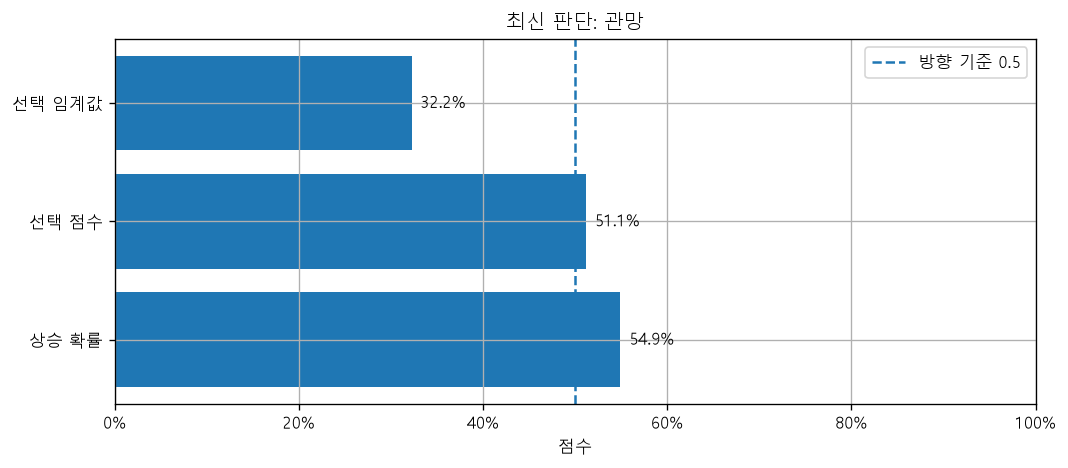

저장된 시각화 파일 수: 22
시각화 폴더: C:\Users\gmb98\Downloads\stock80_output\figures


In [28]:
latest_table = pd.DataFrame(
    {
        "항목": [
            "최신 데이터 날짜",
            "최근 종가",
            "상승 확률",
            "선택 점수",
            "선택 임계값",
            "모델 자체 선택 여부",
            "80% 인증 후 최종 선택 여부",
            "최종 판단",
        ],
        "값": [
            latest["date"],
            latest["close"],
            latest["direction_probability_up"],
            latest["selection_score"],
            best_summary["threshold"],
            latest["model_selected"],
            latest["selected"],
            latest["decision"],
        ],
    }
)

display(latest_table)

latest_scores = pd.Series(
    {
        "상승 확률": latest["direction_probability_up"],
        "선택 점수": latest["selection_score"],
        "선택 임계값": best_summary["threshold"],
    }
)

plt.figure(figsize=(9, 4))
plt.barh(latest_scores.index, latest_scores.values)
plt.axvline(0.5, linestyle="--", label="방향 기준 0.5")
plt.xlim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.title(f"최신 판단: {latest['decision']}")
plt.xlabel("점수")
for position, value in enumerate(latest_scores.values):
    plt.text(value + 0.01, position, f"{value:.1%}", va="center")
plt.legend()
finish_figure("22_latest_decision.png")

print(f"저장된 시각화 파일 수: {len(list(figure_dir.glob('*.png')))}")
print(f"시각화 폴더: {figure_dir.resolve()}")

## 14. 결과 해석 기준

### 결과가 의미 있는 경우

- 강제 정확도가 다수 클래스 기준선보다 높습니다.
- 여러 워크포워드 폴드에서 성능이 한 시기에만 몰리지 않습니다.
- 선택 정확도가 높으면서 선택 비율과 신호 수도 충분합니다.
- 최종 테스트가 검증 구간과 비슷한 경향을 보입니다.
- 상승 신호와 하락 신호가 모두 존재합니다.

### 결과를 신뢰하기 어려운 경우

- 선택 정확도는 높지만 신호가 몇 개뿐입니다.
- 검증에서는 80%인데 최종 테스트에서는 크게 하락합니다.
- 항상 상승 또는 항상 하락만 예측해 기준선과 차이가 없습니다.
- 신뢰구간이 매우 넓습니다.
- 테스트 결과를 본 뒤 특징, 모델, 임계값을 반복해서 수정했습니다.

`80%가 미검증되어 실전 배포 금지`는 코드 실패가 아닙니다. 현재 데이터와 실험 설계에서 목표를 입증하지 못했다는 정상적인 연구 결과입니다.

## 15. 결과 파일 압축

아래 셀은 CSV·JSON·모델 파일과 `figures` 폴더의 PNG 시각화를 하나의 ZIP으로 묶습니다.

In [29]:
output_path = Path(config.output_dir)
archive_path = shutil.make_archive(
    str(output_path),
    "zip",
    root_dir=output_path,
)

print(f"결과 ZIP: {archive_path}")
print(f"포함된 PNG 그래프: {len(list((output_path / 'figures').glob('*.png')))}개")

결과 ZIP: c:\Users\gmb98\Downloads\stock80_output.zip
포함된 PNG 그래프: 22개


## 16. 다음 실험 기록

모델을 변경할 때는 테스트 구간을 그대로 반복 확인하지 말고 다음 내용을 별도 문서에 기록합니다.

| 항목 | 기록 내용 |
|---|---|
| 실험 번호 | 예: EXP-001 |
| 변경 사항 | 특징, 모델, 학습창, 임계값 조건 |
| 변경 이유 | 어떤 오류를 해결하려는지 |
| 개발 구간 결과 | 강제 정확도, 선택 정확도, 선택 비율 |
| 최종 테스트 사용 여부 | 사용 전/사용 후 |
| 결론 | 채택, 보류, 폐기 |
| 한계 | 표본 수, 시기 의존성, 데이터 품질 |

새 아이디어는 새 검증 구간이나 롤링 재평가에서 확인해야 합니다. 같은 테스트 구간을 반복 튜닝에 사용하면 그 구간도 사실상 학습 데이터가 됩니다.